# Daily Root Cause Audit

Foco: granularidad de `HARD_FAIL` y `SOFT_FAIL` en el smoke `daily`.

In [1]:
from __future__ import annotations

import ast
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 220)

RUN_DIR = Path(r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_validation\daily_validate_smoke")
INVENTORY_PARQUET = Path(r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_inventory\daily_inventory_full\daily_inventory_files.parquet")
CURRENT_PARQUET = RUN_DIR / 'daily_current.parquet'
SUMMARY_JSON = RUN_DIR / 'validation_run_summary.json'

assert RUN_DIR.exists(), RUN_DIR
assert CURRENT_PARQUET.exists(), CURRENT_PARQUET
assert INVENTORY_PARQUET.exists(), INVENTORY_PARQUET
print(RUN_DIR)


C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\daily_v2_validation\daily_validate_smoke


In [2]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding='utf-8')) if path.exists() else {}


def parse_listish(value):
    if isinstance(value, list):
        return [str(x) for x in value]
    if isinstance(value, tuple):
        return [str(x) for x in value]
    if isinstance(value, np.ndarray):
        return [str(x) for x in value.tolist()]
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return []
    if isinstance(value, str):
        s = value.strip()
        if not s:
            return []
        try:
            out = json.loads(s)
            if isinstance(out, list):
                return [str(x) for x in out]
        except Exception:
            pass
        try:
            out = ast.literal_eval(s)
            if isinstance(out, (list, tuple, set, np.ndarray)):
                return [str(x) for x in list(out)]
        except Exception:
            pass
        tokens = re.findall(r"'([^']+)'", s)
        if tokens:
            return [str(x) for x in tokens]
        return [s]
    return [str(value)]


def parse_dictish(value):
    if isinstance(value, dict):
        return value
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return {}
    if isinstance(value, str):
        s = value.strip()
        if not s:
            return {}
        try:
            out = json.loads(s)
            return out if isinstance(out, dict) else {'value': out}
        except Exception:
            try:
                out = ast.literal_eval(s)
                return out if isinstance(out, dict) else {'value': out}
            except Exception:
                return {'value': s}
    return {'value': value}


def flatten_tokens(series):
    out = []
    for value in series:
        vals = parse_listish(value)
        out.extend([str(x) for x in vals if str(x).strip()])
    return out

summary = load_json(SUMMARY_JSON)
events = pd.read_parquet(CURRENT_PARQUET).copy()
events['issues_list'] = events['issues'].map(parse_listish)
events['warns_list'] = events['warns'].map(parse_listish)
metrics = pd.json_normalize(events['metrics_json'].map(parse_dictish)).add_prefix('m.')
events = pd.concat([events.reset_index(drop=True), metrics.reset_index(drop=True)], axis=1)
events = events.loc[:, ~events.columns.duplicated()].copy()

for c in ['m.rows_after_parse', 'm.coverage_ratio_vs_business_days', 'm.max_gap_days', 'm.vw_outside_range_rows', 'm.negative_or_zero_ohlc_rows', 'm.negative_volume_rows', 'm.high_low_inversion_rows', 'm.duplicate_dates_rows', 'm.dates_outside_partition_year', 'm.business_days_covered_est', 'm.size_bytes', 'm.v_sum', 'm.vw_mean', 'm.h_max', 'm.l_min']:
    if c in events.columns:
        events[c] = pd.to_numeric(events[c], errors='coerce')

hard = events[events['severity'] == 'HARD_FAIL'].copy()
soft = events[events['severity'] == 'SOFT_FAIL'].copy()

display(Markdown(f'''## Carga
- run_id: `{summary.get("run_id")}`
- files: `{len(events):,}`
- HARD_FAIL: `{len(hard):,}`
- SOFT_FAIL: `{len(soft):,}`'''))


## Carga
- run_id: `daily_validate_smoke`
- files: `5,000`
- HARD_FAIL: `1,716`
- SOFT_FAIL: `3,284`

## 1. Snapshot del smoke

,severity,files,pct
0,SOFT_FAIL,3284,65.68
1,HARD_FAIL,1716,34.32


C:\Users\AlexJ\AppData\Local\Temp\ipykernel_23480\2726985768.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sev_counts, x='severity', y='files', palette={'PASS': '#2a9d8f', 'SOFT_FAIL': '#e9c46a', 'HARD_FAIL': '#e76f51'})


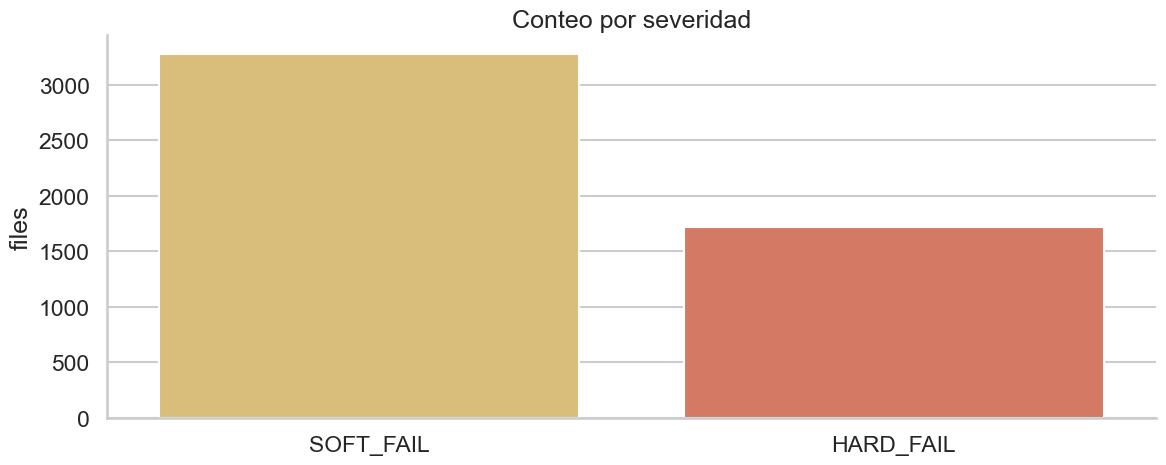

In [3]:
sev_counts = events['severity'].value_counts().rename_axis('severity').reset_index(name='files')
sev_counts['pct'] = 100.0 * sev_counts['files'] / max(len(events), 1)
display(sev_counts)

plt.figure(figsize=(12, 5))
sns.barplot(data=sev_counts, x='severity', y='files', palette={'PASS': '#2a9d8f', 'SOFT_FAIL': '#e9c46a', 'HARD_FAIL': '#e76f51'})
plt.title('Conteo por severidad')
plt.xlabel('')
plt.ylabel('files')
plt.tight_layout()


## 2. Granularidad del HARD_FAIL

,issue,files,pct_of_hard
0,vw_outside_range_rows,1698,98.951049
1,negative_or_zero_ohlc_rowsvw_outside_range_rows,12,0.699301
2,negative_or_zero_ohlc_rows,5,0.291375
3,all_rows_invalid_after_parse,1,0.058275


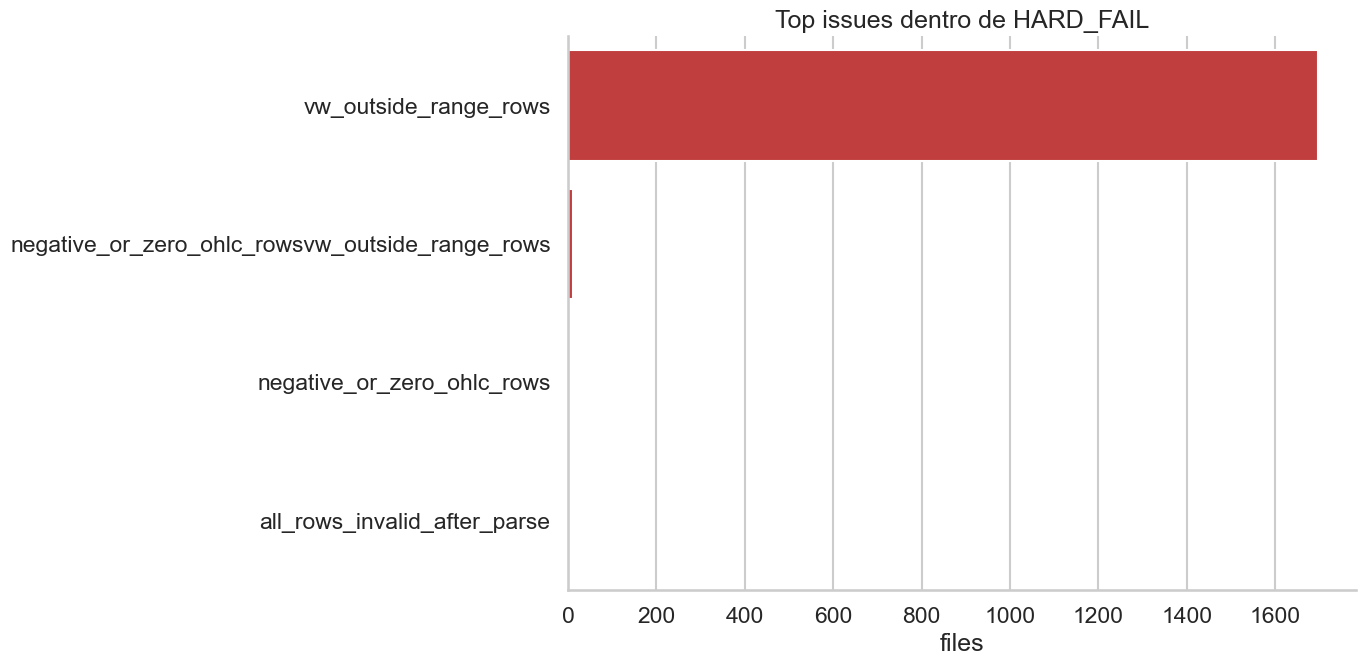

In [4]:
hard_issue_counts = (
    pd.Series(flatten_tokens(hard['issues_list']), dtype='object')
    .value_counts()
    .rename_axis('issue')
    .reset_index(name='files')
)
hard_issue_counts['pct_of_hard'] = 100.0 * hard_issue_counts['files'] / max(len(hard), 1)
display(hard_issue_counts)

plt.figure(figsize=(14, 7))
sns.barplot(data=hard_issue_counts.head(15), y='issue', x='files', color='#d62828')
plt.title('Top issues dentro de HARD_FAIL')
plt.xlabel('files')
plt.ylabel('')
plt.tight_layout()


### Issue dominante: `{dominant_issue}`

,year,files
0,2024,685
1,2025,682
2,2026,331


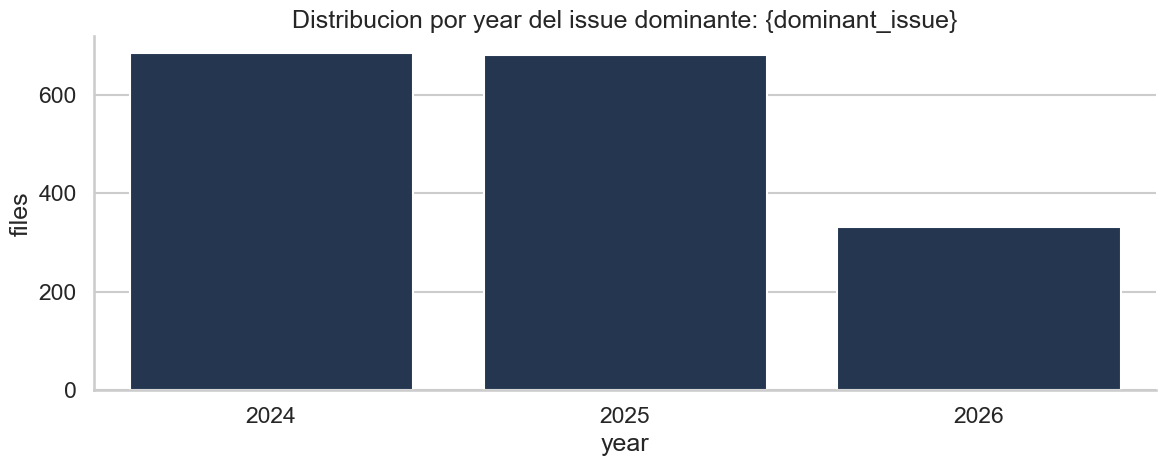

In [5]:
dominant_issue = hard_issue_counts.iloc[0]['issue'] if not hard_issue_counts.empty else None
dominant_df = hard[hard['issues_list'].map(lambda xs: dominant_issue in set(xs))].copy() if dominant_issue else hard.head(0).copy()

display(Markdown(f"### Issue dominante: `{{dominant_issue}}`"))

dominant_year = dominant_df.groupby('year').size().rename_axis('year').reset_index(name='files').sort_values('year')
display(dominant_year)

plt.figure(figsize=(12, 5))
sns.barplot(data=dominant_year, x='year', y='files', color='#1d3557')
plt.title(f'Distribucion por year del issue dominante: {{dominant_issue}}')
plt.xlabel('year')
plt.ylabel('files')
plt.tight_layout()


,ticker,files
0,DECK,3
1,DCOMG,3
2,ABLV,3
3,AATC,3
4,ABTS,3
5,CYN,3
6,CYCN,3
7,CYAN,3
8,CXH,3
9,CXAI,3


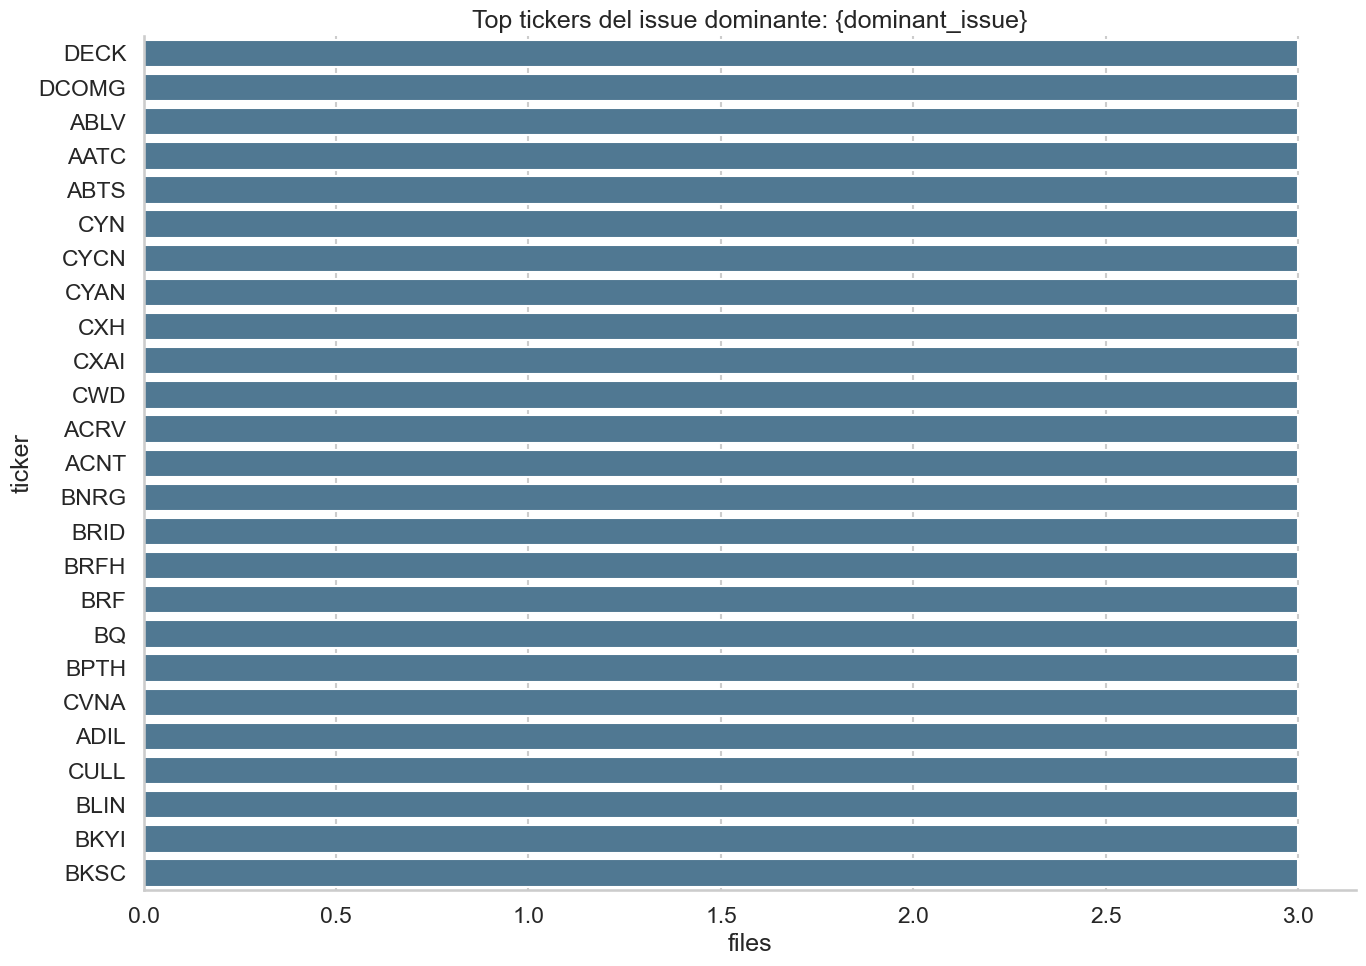

In [6]:
top_tickers_hard = (
    dominant_df.groupby('ticker')
    .size()
    .sort_values(ascending=False)
    .head(25)
    .rename_axis('ticker')
    .reset_index(name='files')
)
display(top_tickers_hard)

plt.figure(figsize=(14, 10))
sns.barplot(data=top_tickers_hard, y='ticker', x='files', color='#457b9d')
plt.title(f'Top tickers del issue dominante: {{dominant_issue}}')
plt.xlabel('files')
plt.ylabel('ticker')
plt.tight_layout()


In [7]:
metric_cols = [c for c in ['m.vw_outside_range_rows', 'm.rows_after_parse', 'm.coverage_ratio_vs_business_days', 'm.max_gap_days'] if c in dominant_df.columns]
show_cols = ['ticker', 'year', 'severity'] + metric_cols + ['file']
display(dominant_df[show_cols].sort_values(metric_cols[:1] if metric_cols else ['ticker'], ascending=False).head(40))


,ticker,year,severity,m.vw_outside_range_rows,m.rows_after_parse,m.coverage_ratio_vs_business_days,m.max_gap_days,file
3190,CAS,2025,HARD_FAIL,168.0,224.0,0.858238,5.0,D:\ohlcv_daily\ticker=CAS\year=2025\day_aggs_CAS_2025.parquet
3211,CA,2024,HARD_FAIL,123.0,216.0,0.824427,6.0,D:\ohlcv_daily\ticker=CA\year=2024\day_aggs_CA_2024.parquet
3577,CGRO,2024,HARD_FAIL,115.0,203.0,0.774809,8.0,D:\ohlcv_daily\ticker=CGRO\year=2024\day_aggs_CGRO_2024.parquet
3745,CIL,2024,HARD_FAIL,106.0,244.0,0.931298,4.0,D:\ohlcv_daily\ticker=CIL\year=2024\day_aggs_CIL_2024.parquet
3746,CIL,2025,HARD_FAIL,103.0,250.0,0.957854,4.0,D:\ohlcv_daily\ticker=CIL\year=2025\day_aggs_CIL_2025.parquet
3578,CGRO,2025,HARD_FAIL,102.0,248.0,0.950192,4.0,D:\ohlcv_daily\ticker=CGRO\year=2025\day_aggs_CGRO_2025.parquet
73,ABI,2025,HARD_FAIL,99.0,124.0,0.475096,5.0,D:\ohlcv_daily\ticker=ABI\year=2025\day_aggs_ABI_2025.parquet
497,AGM.A,2025,HARD_FAIL,96.0,156.0,0.597701,8.0,D:\ohlcv_daily\ticker=AGM.A\year=2025\day_aggs_AGM.A_2025.parquet
1321,ARP,2024,HARD_FAIL,94.0,242.0,0.923664,6.0,D:\ohlcv_daily\ticker=ARP\year=2024\day_aggs_ARP_2024.parquet
2150,BFAC,2024,HARD_FAIL,81.0,175.0,0.667939,10.0,D:\ohlcv_daily\ticker=BFAC\year=2024\day_aggs_BFAC_2024.parquet


## 3. HARD_FAIL residual fuera del issue dominante

In [8]:
other_hard = hard.copy()
if dominant_issue:
    other_hard = other_hard[~other_hard['issues_list'].map(lambda xs: dominant_issue in set(xs))].copy()

other_issue_counts = (
    pd.Series(flatten_tokens(other_hard['issues_list']), dtype='object')
    .value_counts()
    .rename_axis('issue')
    .reset_index(name='files')
)
display(other_issue_counts)
other_cols = [c for c in ['ticker', 'year', 'issues_list', 'warns_list', 'm.negative_or_zero_ohlc_rows', 'file'] if c in other_hard.columns]
display(other_hard[other_cols].sort_values(['ticker', 'year']).head(40))


,issue,files
0,negative_or_zero_ohlc_rowsvw_outside_range_rows,12
1,negative_or_zero_ohlc_rows,5
2,all_rows_invalid_after_parse,1


,ticker,year,issues_list,warns_list,m.negative_or_zero_ohlc_rows,file
9,AAGR,2024,[negative_or_zero_ohlc_rowsvw_outside_range_rows],[dataset_read_incompatible_schemaschema_merge_conflict_ticker_encoding],5.0,D:\ohlcv_daily\ticker=AAGR\year=2024\day_aggs_AAGR_2024.parquet
10,AAGR,2025,[negative_or_zero_ohlc_rowsvw_outside_range_rows],[dataset_read_incompatible_schemaschema_merge_conflict_ticker_encoding],26.0,D:\ohlcv_daily\ticker=AAGR\year=2025\day_aggs_AAGR_2025.parquet
11,AAGR,2026,[negative_or_zero_ohlc_rowsvw_outside_range_rows],[dataset_read_incompatible_schemaschema_merge_conflict_ticker_encodingsuspicious_sparse_year],1.0,D:\ohlcv_daily\ticker=AAGR\year=2026\day_aggs_AAGR_2026.parquet
354,ADYX,2026,[all_rows_invalid_after_parse],[dataset_read_incompatible_schemaschema_merge_conflict_ticker_encoding],NaN,D:\ohlcv_daily\ticker=ADYX\year=2026\day_aggs_ADYX_2026.parquet
444,AFIB,2025,[negative_or_zero_ohlc_rowsvw_outside_range_rows],[dataset_read_incompatible_schemaschema_merge_conflict_ticker_encoding],1.0,D:\ohlcv_daily\ticker=AFIB\year=2025\day_aggs_AFIB_2025.parquet
797,ALPP,2025,[negative_or_zero_ohlc_rowsvw_outside_range_rows],[dataset_read_incompatible_schemaschema_merge_conflict_ticker_encoding],3.0,D:\ohlcv_daily\ticker=ALPP\year=2025\day_aggs_ALPP_2025.parquet
1063,ANTH,2024,[negative_or_zero_ohlc_rows],[dataset_read_incompatible_schemalarge_internal_gap_daysschema_merge_conflict_ticker_encodingsuspicious_sparse_year],2.0,D:\ohlcv_daily\ticker=ANTH\year=2024\day_aggs_ANTH_2024.parquet
1064,ANTH,2025,[negative_or_zero_ohlc_rows],[dataset_read_incompatible_schemalarge_internal_gap_daysschema_merge_conflict_ticker_encodingsuspicious_sparse_year],1.0,D:\ohlcv_daily\ticker=ANTH\year=2025\day_aggs_ANTH_2025.parquet
1257,ARDS,2024,[negative_or_zero_ohlc_rows],[dataset_read_incompatible_schemalarge_internal_gap_daysschema_merge_conflict_ticker_encoding],4.0,D:\ohlcv_daily\ticker=ARDS\year=2024\day_aggs_ARDS_2024.parquet
1258,ARDS,2025,[negative_or_zero_ohlc_rowsvw_outside_range_rows],[dataset_read_incompatible_schemaschema_merge_conflict_ticker_encoding],4.0,D:\ohlcv_daily\ticker=ARDS\year=2025\day_aggs_ARDS_2025.parquet


## 4. Granularidad del SOFT_FAIL

,warn,files,pct_of_soft
0,dataset_read_incompatible_schemaschema_merge_conflict_ticker_encoding,1831,55.755177
1,dataset_read_incompatible_schemaschema_merge_conflict_ticker_encodingsuspicious_sparse_year,1404,42.752741
2,dataset_read_incompatible_schemarows_lt_10schema_merge_conflict_ticker_encodingsuspicious_sparse_year,35,1.065773
3,dataset_read_incompatible_schemalarge_internal_gap_daysschema_merge_conflict_ticker_encodingsuspicious_sparse_year,7,0.213155
4,dataset_read_incompatible_schemalarge_internal_gap_daysrows_lt_10schema_merge_conflict_ticker_encodingsuspicious_sparse_year,5,0.152253
5,dataset_read_incompatible_schemalarge_internal_gap_daysschema_merge_conflict_ticker_encoding,2,0.060901


C:\Users\AlexJ\AppData\Local\Temp\ipykernel_23480\3307398621.py:15: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


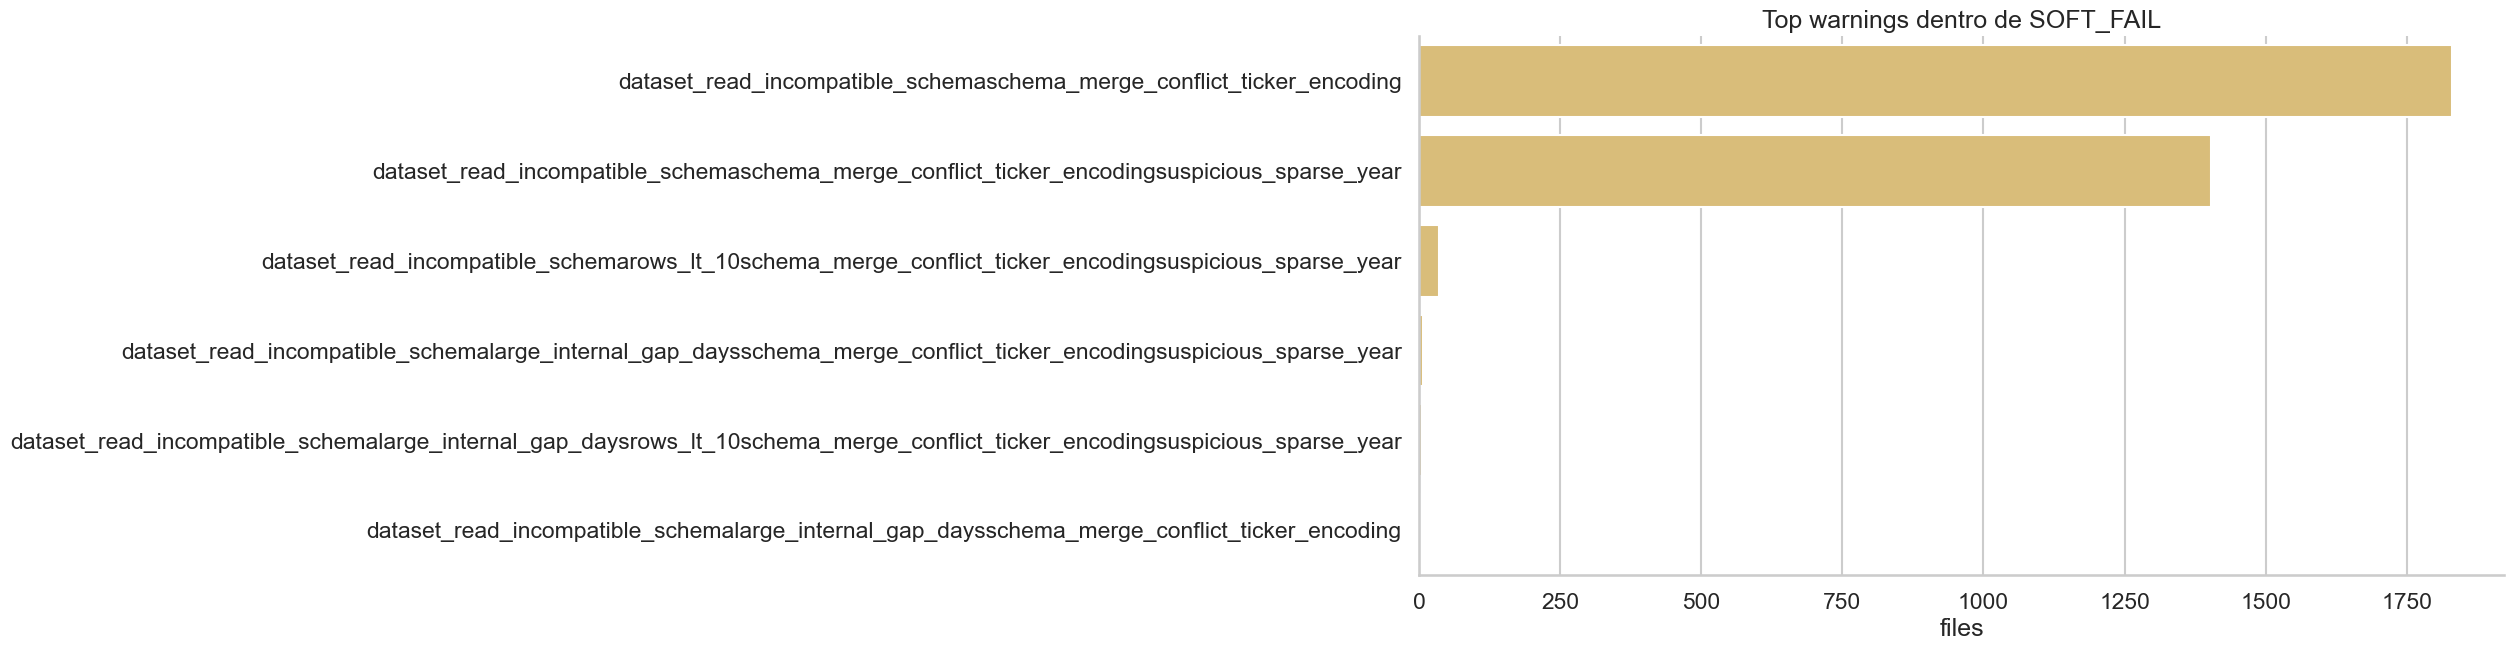

In [9]:
soft_warn_counts = (
    pd.Series(flatten_tokens(soft['warns_list']), dtype='object')
    .value_counts()
    .rename_axis('warn')
    .reset_index(name='files')
)
soft_warn_counts['pct_of_soft'] = 100.0 * soft_warn_counts['files'] / max(len(soft), 1)
display(soft_warn_counts)

plt.figure(figsize=(14, 7))
sns.barplot(data=soft_warn_counts.head(15), y='warn', x='files', color='#e9c46a')
plt.title('Top warnings dentro de SOFT_FAIL')
plt.xlabel('files')
plt.ylabel('')
plt.tight_layout()


### Warning dominante del SOFT_FAIL: `{dominant_soft_warn}`

,year,files
0,2024,920
1,2025,911


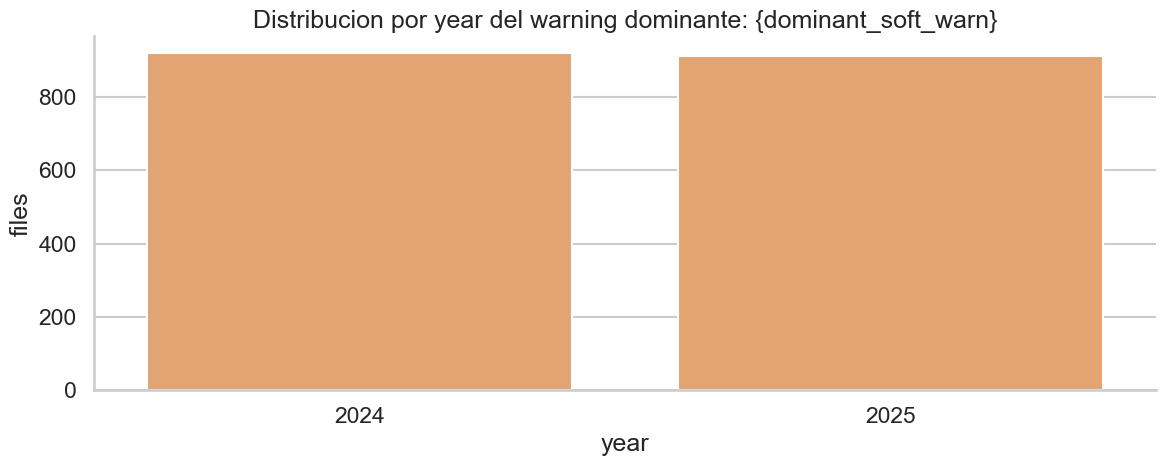

In [10]:
dominant_soft_warn = soft_warn_counts.iloc[0]['warn'] if not soft_warn_counts.empty else None
soft_dominant_df = soft[soft['warns_list'].map(lambda xs: dominant_soft_warn in set(xs))].copy() if dominant_soft_warn else soft.head(0).copy()

display(Markdown(f"### Warning dominante del SOFT_FAIL: `{{dominant_soft_warn}}`"))

soft_year = soft_dominant_df.groupby('year').size().rename_axis('year').reset_index(name='files').sort_values('year')
display(soft_year)

plt.figure(figsize=(12, 5))
sns.barplot(data=soft_year, x='year', y='files', color='#f4a261')
plt.title(f'Distribucion por year del warning dominante: {{dominant_soft_warn}}')
plt.xlabel('year')
plt.ylabel('files')
plt.tight_layout()


,ticker,files
0,DFP,2
1,DFIN,2
2,DES,2
3,DCBO,2
4,DBX,2
5,DBL,2
6,DBI,2
7,DBD,2
8,DB,2
9,DAY,2


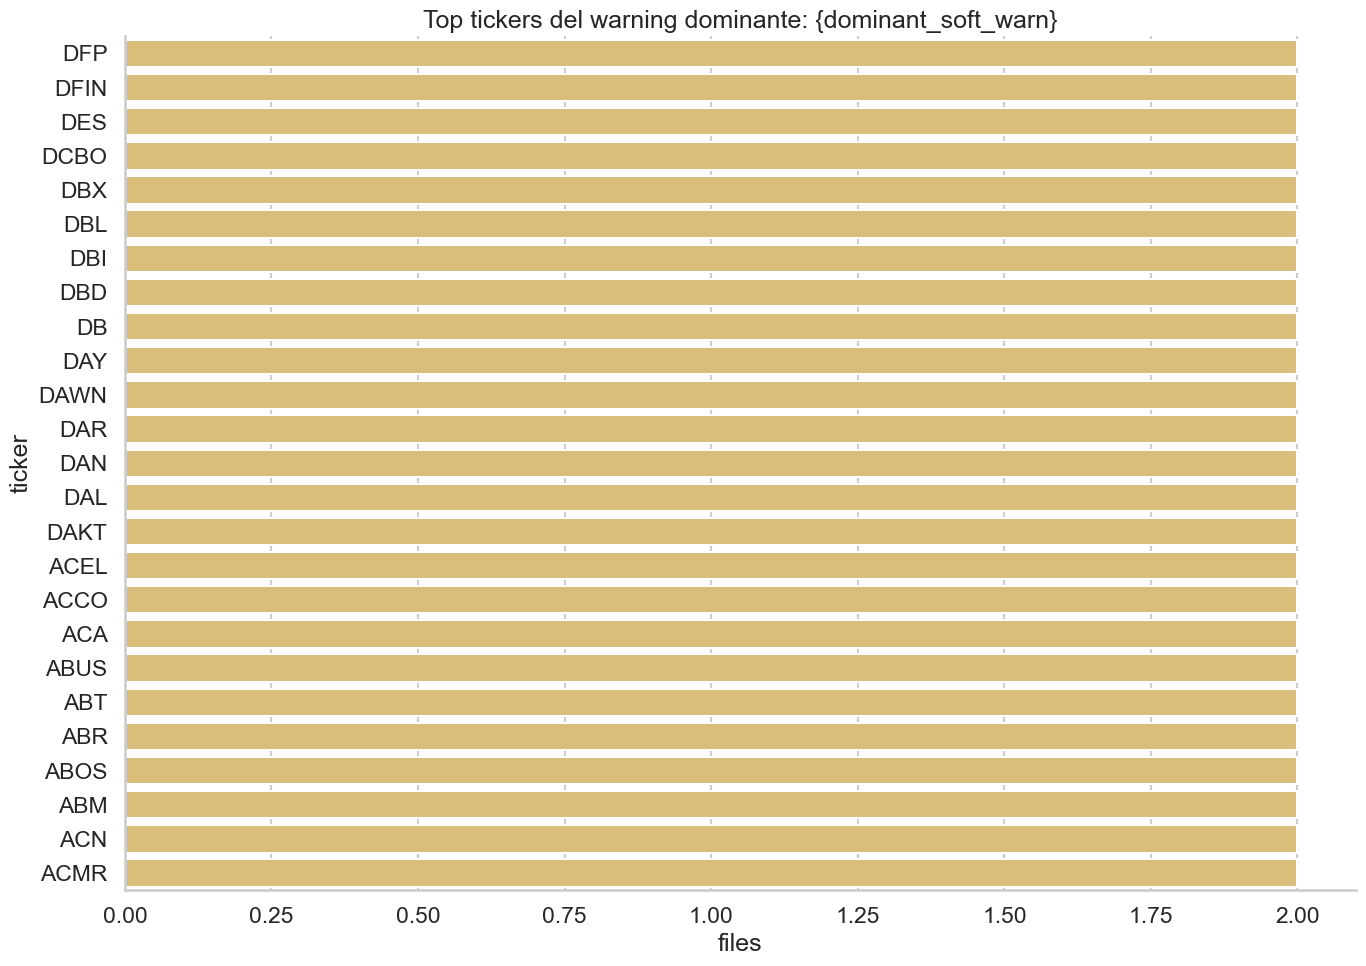

In [11]:
soft_top_tickers = (
    soft_dominant_df.groupby('ticker')
    .size()
    .sort_values(ascending=False)
    .head(25)
    .rename_axis('ticker')
    .reset_index(name='files')
)
display(soft_top_tickers)

plt.figure(figsize=(14, 10))
sns.barplot(data=soft_top_tickers, y='ticker', x='files', color='#e9c46a')
plt.title(f'Top tickers del warning dominante: {{dominant_soft_warn}}')
plt.xlabel('files')
plt.ylabel('ticker')
plt.tight_layout()


## 5. Lectura inicial

In [12]:
top_issue = hard_issue_counts.iloc[0].to_dict() if not hard_issue_counts.empty else {}
top_warn = soft_warn_counts.iloc[0].to_dict() if not soft_warn_counts.empty else {}
summary_df = pd.DataFrame([{
    'hard_fail_files': int(len(hard)),
    'hard_fail_pct': round(100.0 * len(hard) / max(len(events), 1), 3),
    'dominant_hard_issue': top_issue.get('issue'),
    'dominant_hard_issue_files': top_issue.get('files'),
    'dominant_hard_issue_pct_of_hard': round(float(top_issue.get('pct_of_hard', 0.0)), 3) if top_issue else None,
    'dominant_soft_warn': top_warn.get('warn'),
    'dominant_soft_warn_files': top_warn.get('files'),
    'dominant_soft_warn_pct_of_soft': round(float(top_warn.get('pct_of_soft', 0.0)), 3) if top_warn else None,
}])
display(summary_df.T)


,0
hard_fail_files,1716
hard_fail_pct,34.32
dominant_hard_issue,vw_outside_range_rows
dominant_hard_issue_files,1698
dominant_hard_issue_pct_of_hard,98.951
dominant_soft_warn,dataset_read_incompatible_schemaschema_merge_conflict_ticker_encoding
dominant_soft_warn_files,1831
dominant_soft_warn_pct_of_soft,55.755


## 6. Comparativa baseline vs v020

Mismo smoke, pero `v020` a?ade instrumentacion detallada para abrir `vw_outside_range_rows` sin cambiar severidades.

In [13]:
import ast

RUN_V010 = Path(r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_validation\daily_validate_smoke")
RUN_V020 = Path(r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_validation\daily_validate_smoke_v020")


def load_current(run_dir: Path, label: str) -> pd.DataFrame:
    df = pd.read_parquet(run_dir / "daily_current.parquet").copy()
    df["issues_list"] = df["issues"].map(parse_listish)
    df["warns_list"] = df["warns"].map(parse_listish)
    metrics = pd.json_normalize(df["metrics_json"].map(parse_dictish)).add_prefix("m.")
    df = pd.concat([df.reset_index(drop=True), metrics.reset_index(drop=True)], axis=1)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df["version"] = label
    df["file_key"] = df["file"].astype(str)
    return df

cur_010 = load_current(RUN_V010, "v010")
cur_020 = load_current(RUN_V020, "v020")

for frame in [cur_010, cur_020]:
    for c in [
        "m.vw_outside_range_rows",
        "m.vw_below_low_rows",
        "m.vw_above_high_rows",
        "m.vw_outside_range_ratio_pct",
        "m.vw_problem_days",
        "m.vw_problem_days_ratio_pct",
        "m.vw_outside_range_abs_median",
        "m.vw_outside_range_abs_p95",
        "m.vw_outside_range_abs_max",
        "m.vw_outside_range_pct_of_span_median",
        "m.vw_outside_range_pct_of_span_p95",
        "m.vw_outside_range_pct_of_span_max",
        "m.coverage_ratio_vs_business_days",
        "m.rows_after_parse",
        "m.max_gap_days",
    ]:
        if c in frame.columns:
            frame[c] = pd.to_numeric(frame[c], errors="coerce")

cmp = cur_010[["file_key", "ticker", "year", "severity", "issues_list", "warns_list"]].rename(columns={
    "severity": "severity_v010",
    "issues_list": "issues_v010",
    "warns_list": "warns_v010",
}).merge(
    cur_020[["file_key", "severity", "issues_list", "warns_list"] + [c for c in cur_020.columns if c.startswith("m.")]],
    on="file_key",
    how="inner",
).rename(columns={
    "severity": "severity_v020",
    "issues_list": "issues_v020",
    "warns_list": "warns_v020",
})

cmp["transition"] = cmp["severity_v010"] + " -> " + cmp["severity_v020"]
display(pd.DataFrame([{
    "rows_v010": len(cur_010),
    "rows_v020": len(cur_020),
    "matched_rows": len(cmp),
    "hard_v010": int((cur_010["severity"] == "HARD_FAIL").sum()),
    "hard_v020": int((cur_020["severity"] == "HARD_FAIL").sum()),
    "soft_v010": int((cur_010["severity"] == "SOFT_FAIL").sum()),
    "soft_v020": int((cur_020["severity"] == "SOFT_FAIL").sum()),
}]).T)

,0
rows_v010,5000
rows_v020,5000
matched_rows,5000
hard_v010,1716
hard_v020,1716
soft_v010,3284
soft_v020,3284


## 7. Anatomia de `vw_outside_range_rows` en v020

,0
files,1710.000000
median_rows_after_parse,247.500000
median_vw_outside_range_rows,3.000000
median_vw_outside_range_ratio_pct,2.272727
median_vw_problem_days,3.000000
median_coverage_ratio,0.946463
median_max_gap_days,4.000000
median_below_low_rows,1.000000
median_above_high_rows,2.000000


,bucket,files,pct
0,1-5%,653,38.187135
1,<=1%,529,30.935673
2,10-25%,231,13.508772
3,5-10%,172,10.058480
4,>25%,125,7.309942


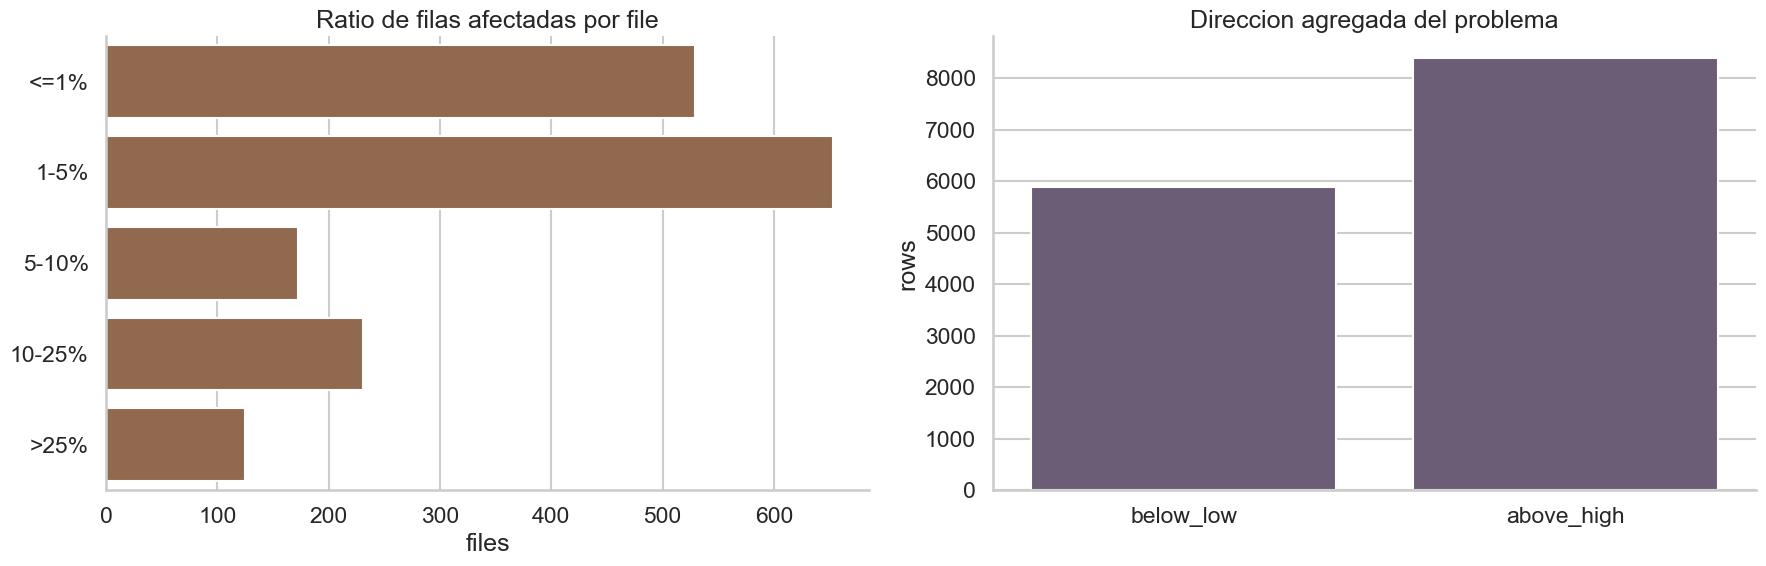

In [14]:
vw020 = cur_020[cur_020["issues_list"].map(lambda xs: "vw_outside_range_rows" in set(xs))].copy()

summary_vw020 = pd.DataFrame([{
    "files": int(len(vw020)),
    "median_rows_after_parse": float(vw020["m.rows_after_parse"].median()),
    "median_vw_outside_range_rows": float(vw020["m.vw_outside_range_rows"].median()),
    "median_vw_outside_range_ratio_pct": float(vw020["m.vw_outside_range_ratio_pct"].median()),
    "median_vw_problem_days": float(vw020["m.vw_problem_days"].median()),
    "median_coverage_ratio": float(vw020["m.coverage_ratio_vs_business_days"].median()),
    "median_max_gap_days": float(vw020["m.max_gap_days"].median()),
    "median_below_low_rows": float(vw020["m.vw_below_low_rows"].median()),
    "median_above_high_rows": float(vw020["m.vw_above_high_rows"].median()),
}])
display(summary_vw020.T)

ratio_bins = pd.cut(
    vw020["m.vw_outside_range_ratio_pct"],
    bins=[-np.inf, 1, 5, 10, 25, np.inf],
    labels=["<=1%", "1-5%", "5-10%", "10-25%", ">25%"],
)
ratio_counts = ratio_bins.value_counts(dropna=False).rename_axis("bucket").reset_index(name="files")
ratio_counts["pct"] = 100.0 * ratio_counts["files"] / max(len(vw020), 1)
display(ratio_counts)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=ratio_counts, y="bucket", x="files", color="#9c6644", ax=axes[0])
axes[0].set_title("Ratio de filas afectadas por file")
axes[0].set_xlabel("files")
axes[0].set_ylabel("")

side = pd.DataFrame([
    {"side": "below_low", "rows": int(vw020["m.vw_below_low_rows"].fillna(0).sum())},
    {"side": "above_high", "rows": int(vw020["m.vw_above_high_rows"].fillna(0).sum())},
])
sns.barplot(data=side, x="side", y="rows", color="#6d597a", ax=axes[1])
axes[1].set_title("Direccion agregada del problema")
axes[1].set_xlabel("")
axes[1].set_ylabel("rows")
plt.tight_layout()

,0
abs_median,0.052175
abs_p95_median,0.156017
abs_max_median,0.198500
pct_span_median,50.627954
pct_span_p95_median,126.124364
pct_span_max_median,131.937756


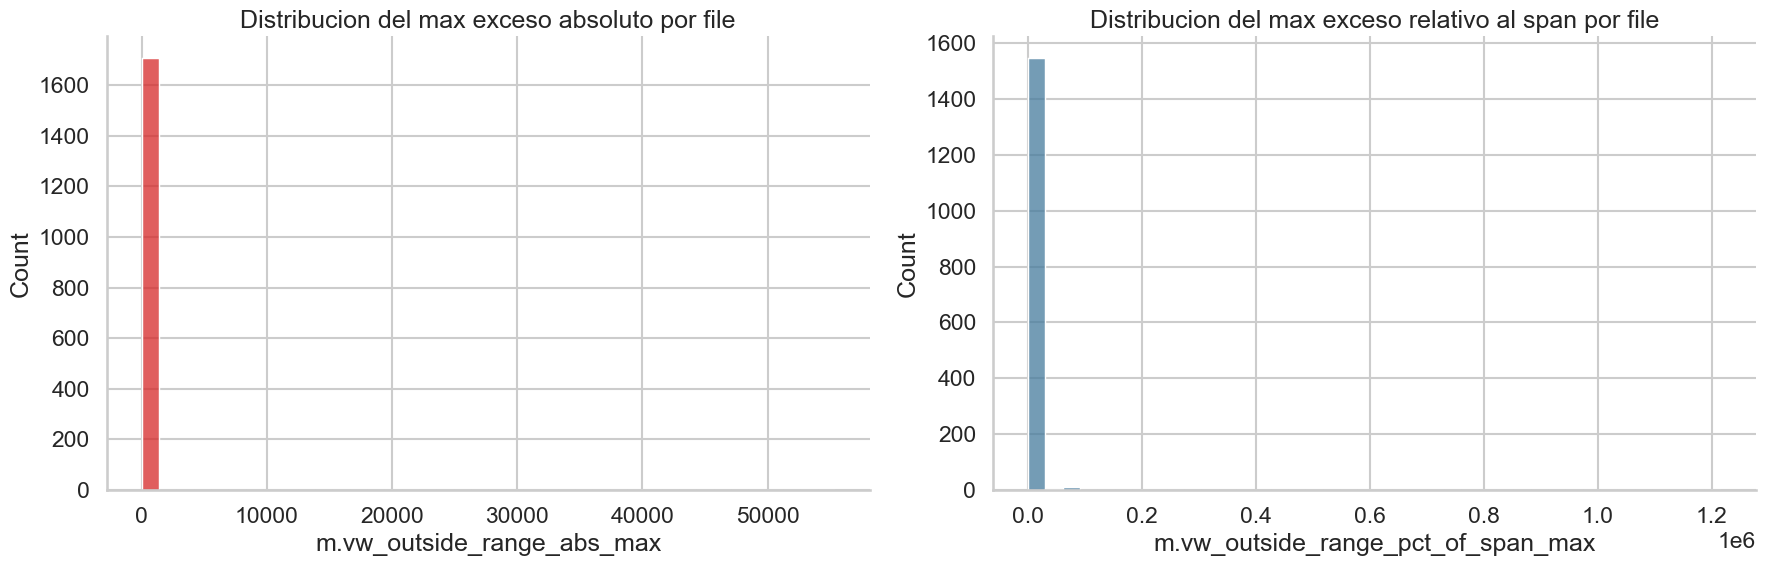

In [15]:
quant_summary = pd.DataFrame([{
    "abs_median": float(vw020["m.vw_outside_range_abs_median"].median()),
    "abs_p95_median": float(vw020["m.vw_outside_range_abs_p95"].median()),
    "abs_max_median": float(vw020["m.vw_outside_range_abs_max"].median()),
    "pct_span_median": float(vw020["m.vw_outside_range_pct_of_span_median"].median()),
    "pct_span_p95_median": float(vw020["m.vw_outside_range_pct_of_span_p95"].median()),
    "pct_span_max_median": float(vw020["m.vw_outside_range_pct_of_span_max"].median()),
}])
display(quant_summary.T)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.histplot(vw020["m.vw_outside_range_abs_max"].dropna(), bins=40, color="#d62828", ax=axes[0])
axes[0].set_title("Distribucion del max exceso absoluto por file")
axes[0].set_xlabel("m.vw_outside_range_abs_max")

sns.histplot(vw020["m.vw_outside_range_pct_of_span_max"].dropna(), bins=40, color="#457b9d", ax=axes[1])
axes[1].set_title("Distribucion del max exceso relativo al span por file")
axes[1].set_xlabel("m.vw_outside_range_pct_of_span_max")
plt.tight_layout()

In [16]:
coverage_split = vw020.copy()
coverage_split["coverage_bucket"] = np.where(
    coverage_split["m.coverage_ratio_vs_business_days"] >= 0.8,
    "normal_or_near_full",
    np.where(
        coverage_split["m.coverage_ratio_vs_business_days"] >= 0.5,
        "partial",
        "very_incomplete",
    ),
)
coverage_summary = (
    coverage_split.groupby("coverage_bucket")
    .agg(
        files=("file_key", "count"),
        median_ratio_pct=("m.vw_outside_range_ratio_pct", "median"),
        median_abs_max=("m.vw_outside_range_abs_max", "median"),
        median_pct_span_max=("m.vw_outside_range_pct_of_span_max", "median"),
        median_problem_days=("m.vw_problem_days", "median"),
    )
    .reset_index()
)
display(coverage_summary)

by_year = (
    coverage_split.groupby("year")
    .agg(
        files=("file_key", "count"),
        median_ratio_pct=("m.vw_outside_range_ratio_pct", "median"),
        median_coverage=("m.coverage_ratio_vs_business_days", "median"),
        median_problem_days=("m.vw_problem_days", "median"),
    )
    .reset_index()
    .sort_values("year")
)
display(by_year)

,coverage_bucket,files,median_ratio_pct,median_abs_max,median_pct_span_max,median_problem_days
0,normal_or_near_full,1013,1.190476,0.29980,139.363014,3.0
1,partial,140,4.906417,0.24995,220.100503,9.0
2,very_incomplete,557,6.818182,0.07310,101.117647,3.0


,year,files,median_ratio_pct,median_coverage,median_problem_days
0,2024,690,1.593625,0.961832,3.0
1,2025,688,1.639344,0.957854,3.0
2,2026,332,4.545455,0.168582,2.0


In [17]:
example_cols = [
    "ticker", "year", "severity", "m.vw_outside_range_rows", "m.vw_below_low_rows", "m.vw_above_high_rows",
    "m.vw_outside_range_ratio_pct", "m.vw_problem_days", "m.coverage_ratio_vs_business_days",
    "m.vw_outside_range_abs_max", "m.vw_outside_range_pct_of_span_max",
    "m.vw_outside_range_rows_top_by_abs", "m.vw_outside_range_rows_top_by_pct_of_span", "m.vw_problem_dates_top", "file"
]
example_cols = [c for c in example_cols if c in vw020.columns]

display(Markdown("### Top files por ratio del problema"))
display(vw020[example_cols].sort_values(["m.vw_outside_range_ratio_pct", "m.vw_outside_range_rows"], ascending=False).head(1).T)

display(Markdown("### Top files por exceso relativo al span"))
display(vw020[example_cols].sort_values(["m.vw_outside_range_pct_of_span_max", "m.vw_outside_range_abs_max"], ascending=False).head(1).T)

### Top files por ratio del problema

,360
ticker,AEBIV
year,2025
severity,HARD_FAIL
m.vw_outside_range_rows,1.0
m.vw_below_low_rows,0.0
m.vw_above_high_rows,1.0
m.vw_outside_range_ratio_pct,100.0
m.vw_problem_days,1.0
m.coverage_ratio_vs_business_days,0.003831
m.vw_outside_range_abs_max,13.2431


### Top files por exceso relativo al span

,628
ticker,AIRT
year,2026
severity,HARD_FAIL
m.vw_outside_range_rows,12.0
m.vw_below_low_rows,2.0
m.vw_above_high_rows,10.0
m.vw_outside_range_ratio_pct,30.0
m.vw_problem_days,12.0
m.coverage_ratio_vs_business_days,0.153257
m.vw_outside_range_abs_max,1.217


## 8. Comparativa `v020` vs `v030`

,rows_v020,rows_v030,hard_v020,hard_v030,soft_v020,soft_v030
0,5000,5000,1716,950,3284,4050


,transition,files
0,SOFT_FAIL -> SOFT_FAIL,3284
1,HARD_FAIL -> HARD_FAIL,950
2,HARD_FAIL -> SOFT_FAIL,766


,subtype,files,pct
0,severe,943,55.146199
1,material,631,36.900585
2,minor,136,7.953216


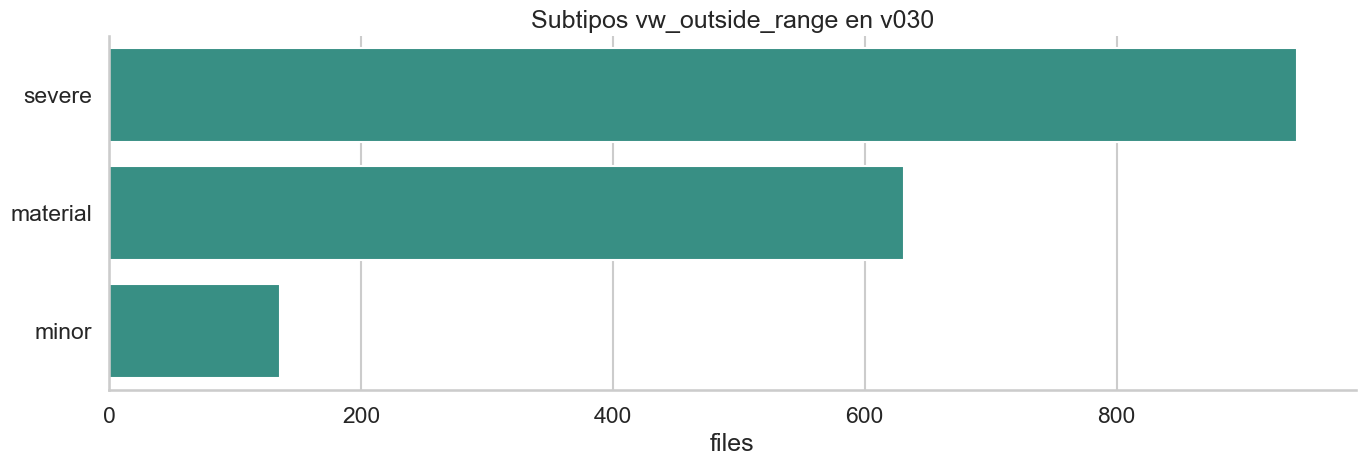

In [18]:
import ast
import json
from pathlib import Path

RUN_V020 = Path(r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_validation\daily_validate_smoke_v020")
RUN_V030 = Path(r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_validation\daily_validate_smoke_v030")

def parse_listish_v3(v):
    if isinstance(v, list):
        return v
    if isinstance(v, tuple):
        return list(v)
    if isinstance(v, str):
        s = v.strip()
        if not s:
            return []
        try:
            x = json.loads(s)
            if isinstance(x, list):
                return x
        except Exception:
            pass
        try:
            x = ast.literal_eval(s)
            if isinstance(x, (list, tuple, set)):
                return list(x)
        except Exception:
            pass
        return [s]
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return []
    return [v]

def flatten_tokens_v3(values):
    out = []
    for value in values:
        if value is None or (isinstance(value, float) and pd.isna(value)):
            continue
        if isinstance(value, (list, tuple, set)):
            for item in value:
                if isinstance(item, (list, tuple, set)):
                    out.extend(flatten_tokens_v3(list(item)))
                elif item is not None and not (isinstance(item, float) and pd.isna(item)):
                    out.append(str(item))
        else:
            out.append(str(value))
    return out

def parse_dictish_v3(v):
    if isinstance(v, dict):
        return v
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return {}
    s = str(v).strip()
    if not s:
        return {}
    try:
        x = json.loads(s)
        if isinstance(x, dict):
            return x
    except Exception:
        pass
    try:
        x = ast.literal_eval(s)
        if isinstance(x, dict):
            return x
    except Exception:
        pass
    return {}

def load_daily_current(run_dir, label):
    df = pd.read_parquet(run_dir / 'daily_current.parquet').copy()
    df['issues_list'] = df['issues'].map(lambda x: flatten_tokens_v3([parse_listish_v3(x)]))
    df['warns_list'] = df['warns'].map(lambda x: flatten_tokens_v3([parse_listish_v3(x)]))
    metrics = pd.json_normalize(df['metrics_json'].map(parse_dictish_v3)).add_prefix('m.')
    df = pd.concat([df.reset_index(drop=True), metrics.reset_index(drop=True)], axis=1)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df['version'] = label
    df['file_key'] = df['file'].astype(str)
    return df

cur_020_v3 = load_daily_current(RUN_V020, 'v020')
cur_030_v3 = load_daily_current(RUN_V030, 'v030')

cmp_v2030 = (
    cur_020_v3[['file_key','ticker','year','severity']]
    .rename(columns={'severity':'severity_v020'})
    .merge(
        cur_030_v3[['file_key','severity','issues_list','warns_list','m.vw_outside_range_subtype','m.vw_outside_range_ratio_pct','m.vw_problem_days','m.coverage_ratio_vs_business_days','m.vw_outside_range_abs_max']],
        on='file_key',
        how='inner'
    )
    .rename(columns={'severity':'severity_v030'})
)
cmp_v2030['transition'] = cmp_v2030['severity_v020'] + ' -> ' + cmp_v2030['severity_v030']

display(pd.DataFrame([{
    'rows_v020': int(len(cur_020_v3)),
    'rows_v030': int(len(cur_030_v3)),
    'hard_v020': int((cur_020_v3['severity']=='HARD_FAIL').sum()),
    'hard_v030': int((cur_030_v3['severity']=='HARD_FAIL').sum()),
    'soft_v020': int((cur_020_v3['severity']=='SOFT_FAIL').sum()),
    'soft_v030': int((cur_030_v3['severity']=='SOFT_FAIL').sum()),
}]))

display(cmp_v2030['transition'].value_counts().rename_axis('transition').reset_index(name='files'))

vw030 = cur_030_v3[cur_030_v3['m.vw_outside_range_subtype'].notna()].copy()
subtype_counts = vw030['m.vw_outside_range_subtype'].value_counts().rename_axis('subtype').reset_index(name='files')
subtype_counts['pct'] = 100.0 * subtype_counts['files'] / max(len(vw030), 1)
display(subtype_counts)

plt.figure(figsize=(14,5))
sns.barplot(data=subtype_counts, y='subtype', x='files', color='#2a9d8f')
plt.title('Subtipos vw_outside_range en v030')
plt.xlabel('files')
plt.ylabel('')
plt.tight_layout()
plt.show()


## 9. Granularidad de `v030` y peor subconjunto `severe`

In [19]:
severe030 = cur_030_v3[cur_030_v3['m.vw_outside_range_subtype'] == 'severe'].copy()
material030 = cur_030_v3[cur_030_v3['m.vw_outside_range_subtype'] == 'material'].copy()
minor030 = cur_030_v3[cur_030_v3['m.vw_outside_range_subtype'] == 'minor'].copy()

summary_v030 = pd.DataFrame([
    {
        'subtype': 'severe',
        'files': int(len(severe030)),
        'median_ratio_pct': pd.to_numeric(severe030.get('m.vw_outside_range_ratio_pct'), errors='coerce').median(),
        'median_problem_days': pd.to_numeric(severe030.get('m.vw_problem_days'), errors='coerce').median(),
        'median_coverage': pd.to_numeric(severe030.get('m.coverage_ratio_vs_business_days'), errors='coerce').median(),
        'median_abs_max': pd.to_numeric(severe030.get('m.vw_outside_range_abs_max'), errors='coerce').median(),
    },
    {
        'subtype': 'material',
        'files': int(len(material030)),
        'median_ratio_pct': pd.to_numeric(material030.get('m.vw_outside_range_ratio_pct'), errors='coerce').median(),
        'median_problem_days': pd.to_numeric(material030.get('m.vw_problem_days'), errors='coerce').median(),
        'median_coverage': pd.to_numeric(material030.get('m.coverage_ratio_vs_business_days'), errors='coerce').median(),
        'median_abs_max': pd.to_numeric(material030.get('m.vw_outside_range_abs_max'), errors='coerce').median(),
    },
    {
        'subtype': 'minor',
        'files': int(len(minor030)),
        'median_ratio_pct': pd.to_numeric(minor030.get('m.vw_outside_range_ratio_pct'), errors='coerce').median(),
        'median_problem_days': pd.to_numeric(minor030.get('m.vw_problem_days'), errors='coerce').median(),
        'median_coverage': pd.to_numeric(minor030.get('m.coverage_ratio_vs_business_days'), errors='coerce').median(),
        'median_abs_max': pd.to_numeric(minor030.get('m.vw_outside_range_abs_max'), errors='coerce').median(),
    },
])
display(summary_v030)

worst_severe = severe030[[
    'ticker','year','severity','m.vw_outside_range_ratio_pct','m.vw_problem_days','m.coverage_ratio_vs_business_days','m.vw_outside_range_abs_max','m.vw_outside_range_trigger_reasons','file'
]].sort_values(['m.vw_outside_range_ratio_pct','m.vw_outside_range_abs_max'], ascending=[False,False]).head()
display(worst_severe)


,subtype,files,median_ratio_pct,median_problem_days,median_coverage,median_abs_max
0,severe,943,2.800000,5.0,0.950192,0.5766
1,material,631,2.272727,2.0,0.381679,0.0738
2,minor,136,0.400000,1.0,0.959843,0.0171


,ticker,year,severity,m.vw_outside_range_ratio_pct,m.vw_problem_days,m.coverage_ratio_vs_business_days,m.vw_outside_range_abs_max,m.vw_outside_range_trigger_reasons,file
360,AEBIV,2025,HARD_FAIL,100.000000,1.0,0.003831,13.2431,"[ratio_ge_10pct, abs_max_ge_1, pct_of_vw_max_ge_5pct]",D:\ohlcv_daily\ticker=AEBIV\year=2025\day_aggs_AEBIV_2025.parquet
74,ABI,2026,HARD_FAIL,88.636364,39.0,0.168582,6.2373,"[ratio_ge_10pct, problem_days_ge_10, abs_max_ge_1, pct_of_vw_max_ge_5pct]",D:\ohlcv_daily\ticker=ABI\year=2026\day_aggs_ABI_2026.parquet
2317,BIO.B,2025,HARD_FAIL,85.714286,18.0,0.080460,13.7021,"[ratio_ge_10pct, problem_days_ge_10, abs_max_ge_1, pct_of_vw_max_ge_5pct]",D:\ohlcv_daily\ticker=BIO.B\year=2025\day_aggs_BIO.B_2025.parquet
3190,CAS,2025,HARD_FAIL,75.000000,168.0,0.858238,32.6235,"[ratio_ge_10pct, problem_days_ge_10, abs_max_ge_1, pct_of_vw_max_ge_5pct]",D:\ohlcv_daily\ticker=CAS\year=2025\day_aggs_CAS_2025.parquet
928,AMPE,2025,HARD_FAIL,67.816092,59.0,0.333333,0.0621,"[ratio_ge_10pct, problem_days_ge_10, pct_of_vw_max_ge_5pct]",D:\ohlcv_daily\ticker=AMPE\year=2025\day_aggs_AMPE_2025.parquet


## 10. Inspeccion visual file a file del peor subconjunto


## Caso seleccionado
- `ticker`: `AEBIV`
- `year`: `2025`
- `subtype`: `severe`
- `severity`: `HARD_FAIL`
- `ratio_pct`: `100.0`
- `problem_days`: `1.0`
- `coverage`: `0.0038314176245210726`
- `abs_max`: `13.243099999999998`
- `trigger_reasons`: `['ratio_ge_10pct', 'abs_max_ge_1', 'pct_of_vw_max_ge_5pct']`
- `file`: `D:\ohlcv_daily\ticker=AEBIV\year=2025\day_aggs_AEBIV_2025.parquet`


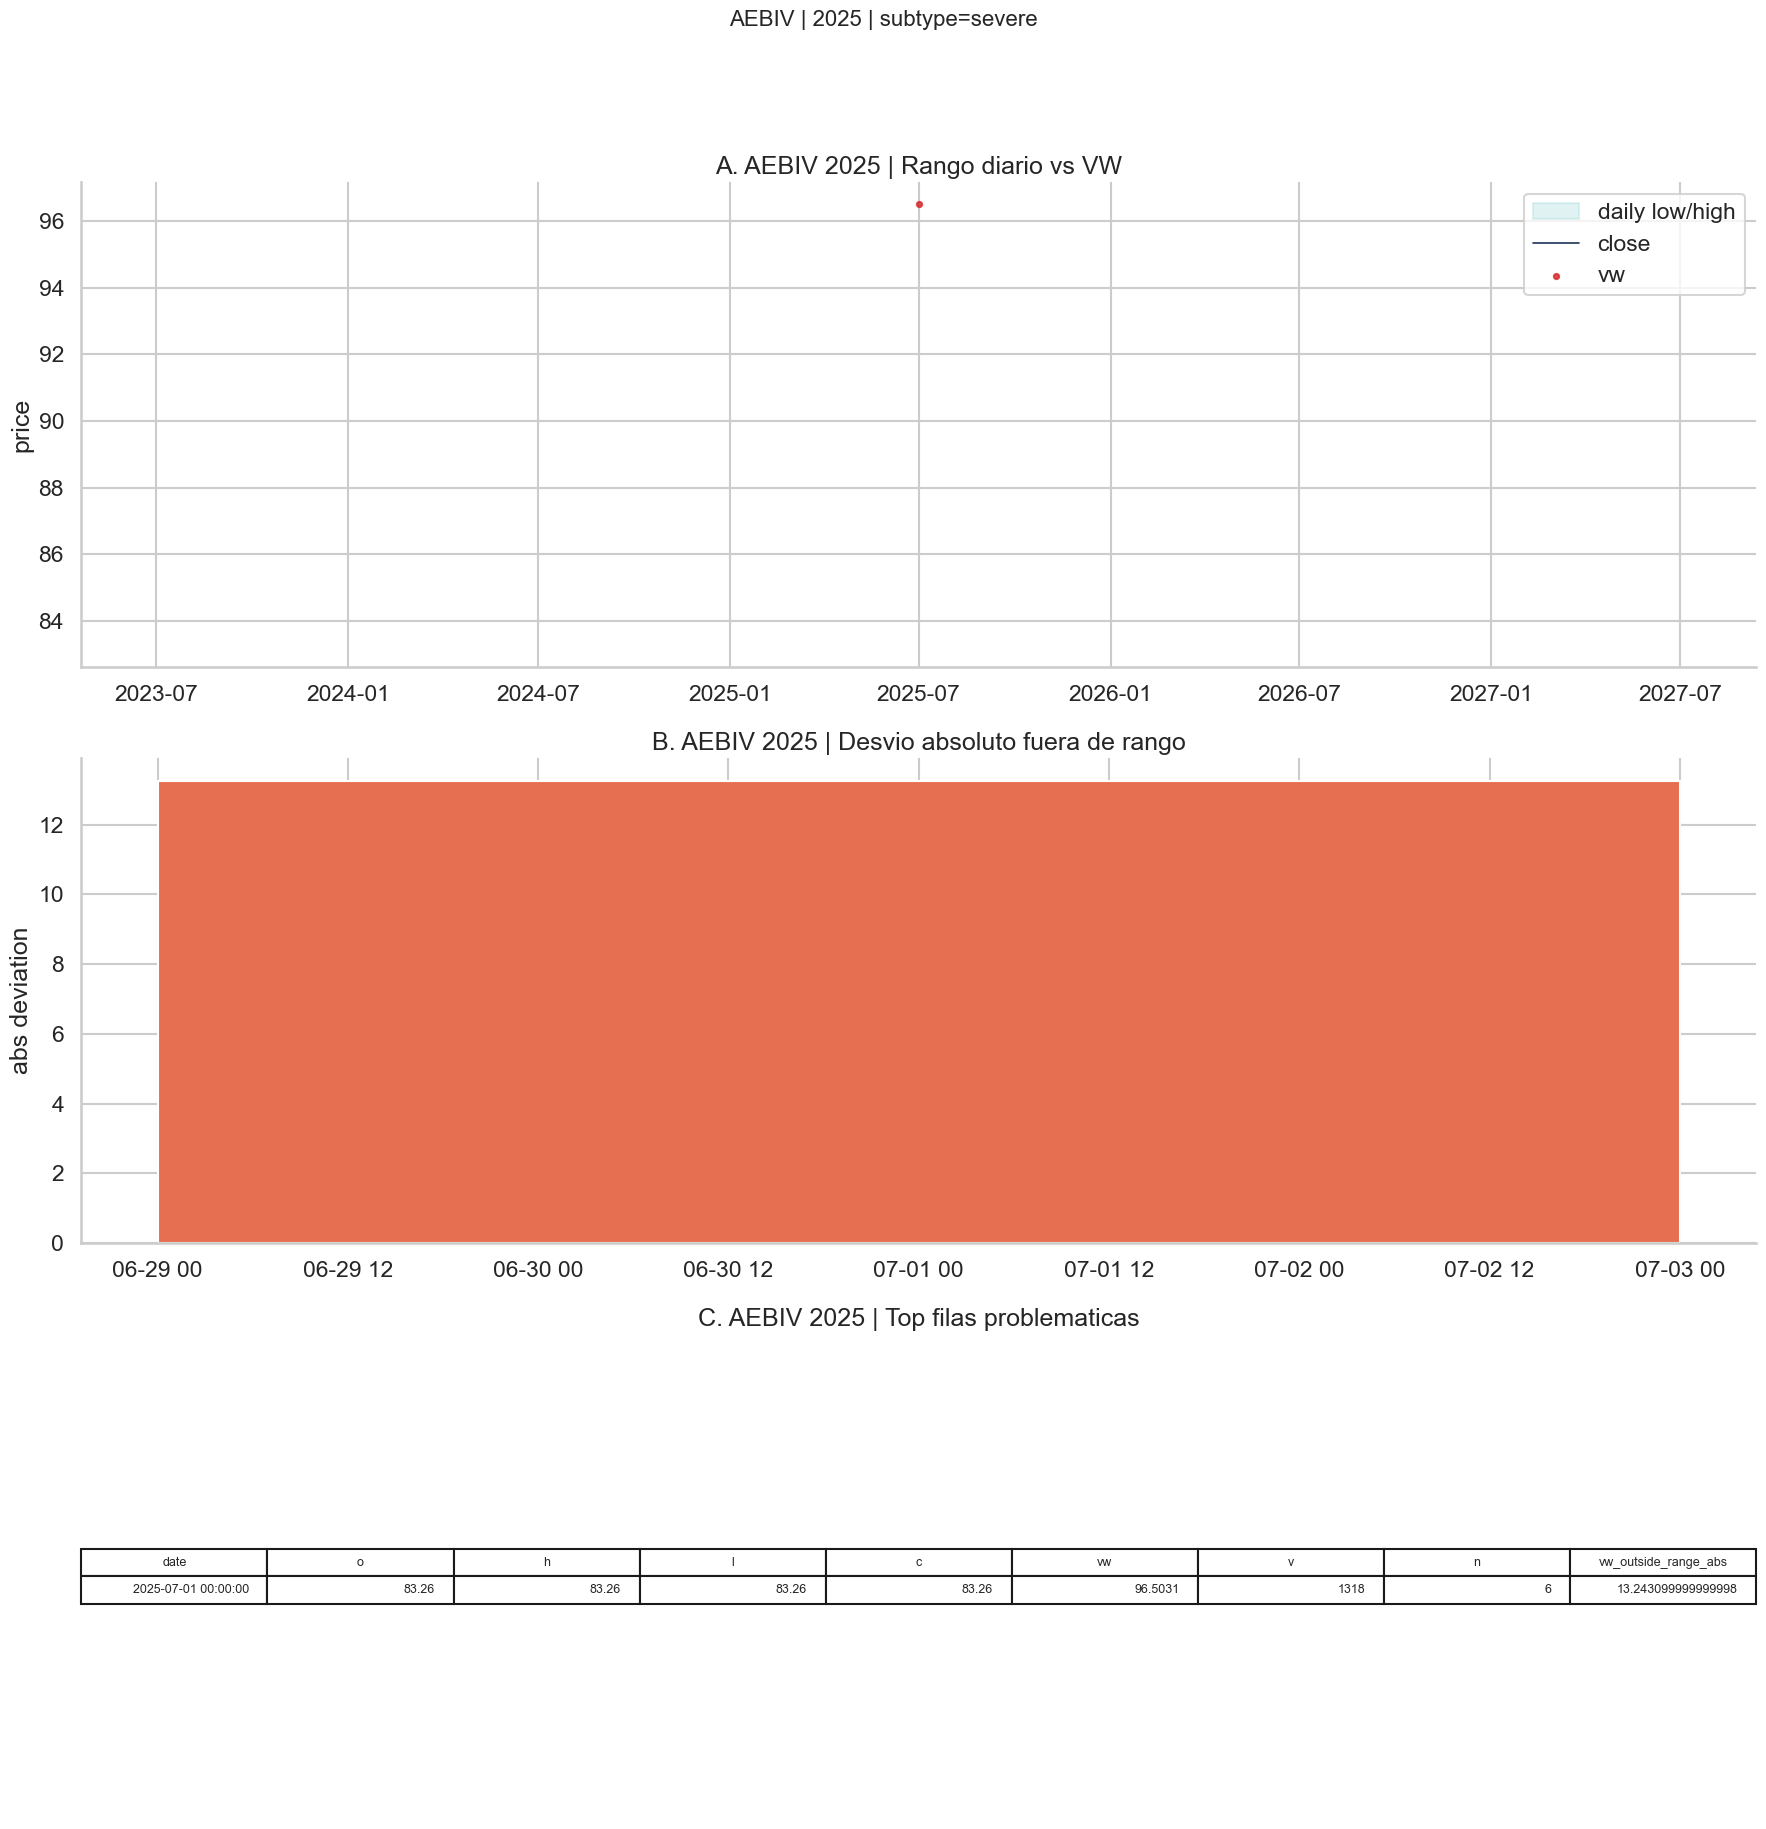

In [20]:
import ipywidgets as widgets
from IPython.display import clear_output

inspect_df = cur_030_v3[cur_030_v3['m.vw_outside_range_subtype'].isin(['severe','material','minor'])].copy()
inspect_df = inspect_df.sort_values(['m.vw_outside_range_ratio_pct','m.vw_outside_range_abs_max'], ascending=[False,False]).reset_index(drop=True)

for c in ['m.vw_outside_range_ratio_pct','m.vw_problem_days','m.coverage_ratio_vs_business_days','m.vw_outside_range_abs_max']:
    if c in inspect_df.columns:
        inspect_df[c] = pd.to_numeric(inspect_df[c], errors='coerce')

def load_daily_file_view(path_str):
    df = pd.read_parquet(path_str).copy()
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    for c in ['o','h','l','c','v','vw','n','t']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna(subset=['date','h','l','vw']).sort_values('date').copy()
    df['vw_below_low_flag'] = (df['v'] > 0) & (df['vw'] < df['l'])
    df['vw_above_high_flag'] = (df['v'] > 0) & (df['vw'] > df['h'])
    df['vw_outside_range_flag'] = df['vw_below_low_flag'] | df['vw_above_high_flag']
    df['vw_outside_range_abs'] = (df[['l','h']].assign(low_gap=(df['l'] - df['vw']).clip(lower=0), high_gap=(df['vw'] - df['h']).clip(lower=0))[['low_gap','high_gap']].max(axis=1))
    return df

def build_case_options(df):
    opts = []
    for i, row in df.iterrows():
        opts.append((
            f"{i:04d} | {row['ticker']} | {row['year']} | subtype={row.get('m.vw_outside_range_subtype')} | ratio={row.get('m.vw_outside_range_ratio_pct', float('nan')):.2f}% | abs_max={row.get('m.vw_outside_range_abs_max', float('nan')):.4f}",
            i,
        ))
    return opts

def get_filtered_df(subtype, ticker, year):
    x = inspect_df.copy()
    if subtype != '__ALL__':
        x = x[x['m.vw_outside_range_subtype'] == subtype].copy()
    if ticker != '__ALL__':
        x = x[x['ticker'].astype(str) == str(ticker)].copy()
    if year != '__ALL__':
        x = x[pd.to_numeric(x['year'], errors='coerce') == int(year)].copy()
    return x.reset_index(drop=True)

def refresh_options(*_):
    x = get_filtered_df(subtype_dd.value, ticker_dd.value, year_dd.value)
    case_dd.options = build_case_options(x)
    if case_dd.options:
        case_dd.value = case_dd.options[0][1]
    else:
        case_dd.options = []
        case_dd.value = None

    
def render_case(*_):
        x = get_filtered_df(subtype_dd.value, ticker_dd.value, year_dd.value)
        clear_output(wait=True)
        display(controls)
        if x.empty or case_dd.value is None:
            display(Markdown('## Sin casos para esta seleccion'))
            return
        row = x.iloc[int(case_dd.value)]
        df = load_daily_file_view(row['file'])
        problem = df[df['vw_outside_range_flag']].copy()

        display(Markdown(f"""
## Caso seleccionado
- `ticker`: `{row['ticker']}`
- `year`: `{row['year']}`
- `subtype`: `{row.get('m.vw_outside_range_subtype')}`
- `severity`: `{row['severity']}`
- `ratio_pct`: `{row.get('m.vw_outside_range_ratio_pct')}`
- `problem_days`: `{row.get('m.vw_problem_days')}`
- `coverage`: `{row.get('m.coverage_ratio_vs_business_days')}`
- `abs_max`: `{row.get('m.vw_outside_range_abs_max')}`
- `trigger_reasons`: `{row.get('m.vw_outside_range_trigger_reasons')}`
- `file`: `{row['file']}`
"""))

        fig, axes = plt.subplots(3, 1, figsize=(18, 18))

        ax = axes[0]
        ax.fill_between(df['date'], df['l'], df['h'], color='#a8dadc', alpha=0.35, label='daily low/high')
        ax.plot(df['date'], df['c'], color='#1d3557', lw=1.2, label='close')
        ax.scatter(df['date'], df['vw'], s=14, c=np.where(df['vw_outside_range_flag'], '#d62828', '#457b9d'), alpha=0.8, label='vw')
        ax.set_title(f"A. {row['ticker']} {row['year']} | Rango diario vs VW")
        ax.legend(loc='best')
        ax.set_ylabel('price')

        ax = axes[1]
        if not problem.empty:
            ax.bar(problem['date'], problem['vw_outside_range_abs'], color='#e76f51', width=4)
        ax.set_title(f"B. {row['ticker']} {row['year']} | Desvio absoluto fuera de rango")
        ax.set_ylabel('abs deviation')

        ax = axes[2]
        top_problem = problem[['date','o','h','l','c','vw','v','n','vw_outside_range_abs']].sort_values('vw_outside_range_abs', ascending=False).head(12).copy() if not problem.empty else pd.DataFrame(columns=['date','o','h','l','c','vw','v','n','vw_outside_range_abs'])
        ax.axis('off')
        tbl = ax.table(cellText=top_problem.values, colLabels=top_problem.columns, loc='center')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1, 1.4)
        ax.set_title(f"C. {row['ticker']} {row['year']} | Top filas problematicas")

        fig.suptitle(f"{row['ticker']} | {row['year']} | subtype={row.get('m.vw_outside_range_subtype')}", fontsize=16, y=1.02)
        plt.tight_layout(rect=[0,0,1,0.98])
        plt.show()

subtype_dd = widgets.Dropdown(options=['__ALL__'] + sorted([str(x) for x in inspect_df['m.vw_outside_range_subtype'].dropna().unique().tolist()]), value='__ALL__', description='Subtype', layout=widgets.Layout(width='350px'))
ticker_dd = widgets.Dropdown(options=['__ALL__'] + sorted(inspect_df['ticker'].astype(str).unique().tolist()), value='__ALL__', description='Ticker', layout=widgets.Layout(width='250px'))
year_dd = widgets.Dropdown(options=['__ALL__'] + sorted([int(x) for x in pd.to_numeric(inspect_df['year'], errors='coerce').dropna().astype(int).unique().tolist()]), value='__ALL__', description='Year', layout=widgets.Layout(width='220px'))
case_dd = widgets.Dropdown(options=[], description='Caso', layout=widgets.Layout(width='1200px'))
controls = widgets.VBox([widgets.HBox([subtype_dd, ticker_dd, year_dd]), case_dd])

subtype_dd.observe(lambda change: (refresh_options(), render_case()) if change['name']=='value' else None, names='value')
ticker_dd.observe(lambda change: (refresh_options(), render_case()) if change['name']=='value' else None, names='value')
year_dd.observe(lambda change: (refresh_options(), render_case()) if change['name']=='value' else None, names='value')
case_dd.observe(lambda change: render_case() if change['name']=='value' else None, names='value')

refresh_options()
display(controls)
render_case()


## Resumen estructural ticker-year

,tickers_total,contiguous_tickers,non_contiguous_tickers,pct_contiguous_tickers,missing_year_rows
0,12230,10655,1575,87.1218,10063


## Top tickers con mas years faltantes dentro del span observado

,ticker,start_year_observed,end_year_observed,unique_years_observed,expected_years_in_span,missing_years_in_span_count,missing_years_in_span
0,AACB,2005,2026,3,22,19,"[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]"
1,AGCC,2005,2026,3,22,19,"[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]"
2,AGH,2005,2026,3,22,19,"[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]"
3,ASBP,2005,2026,3,22,19,"[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]"
4,BMM,2005,2026,3,22,19,"[2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]"


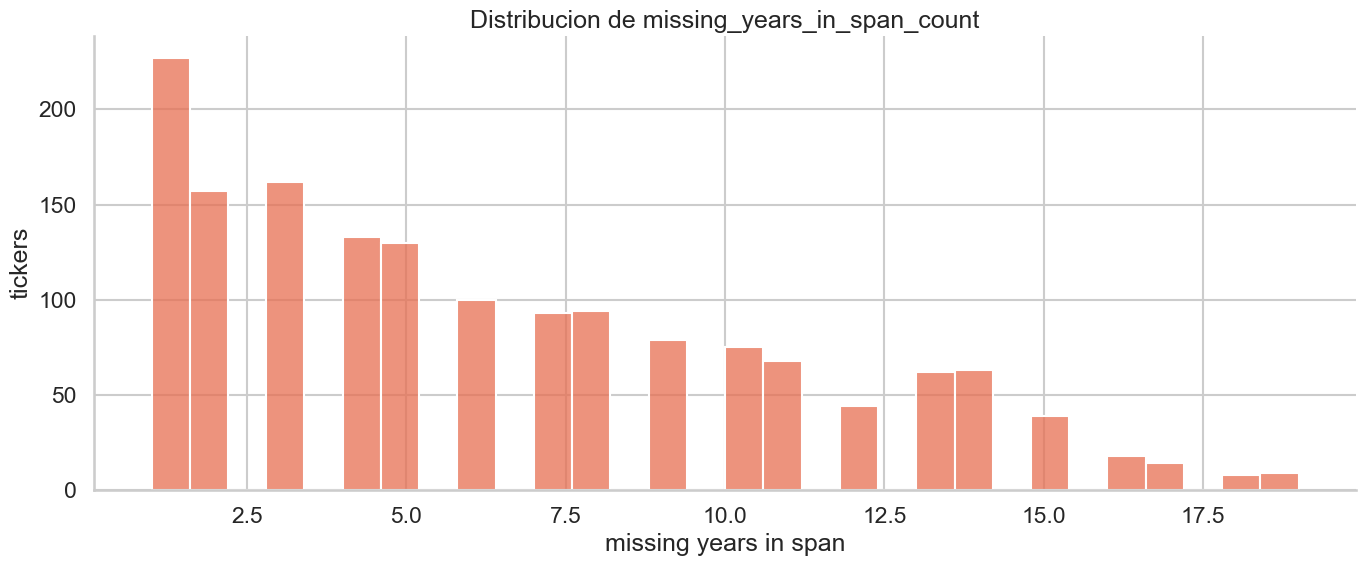

## Exactamente que ticker-year falta

,ticker,missing_year,start_year_observed,end_year_observed
0,AAA,2008,2005,2026
1,AAA,2009,2005,2026
2,AAA,2010,2005,2026
3,AAA,2011,2005,2026
4,AAA,2012,2005,2026
5,AAA,2013,2005,2026
6,AAA,2014,2005,2026
7,AAA,2015,2005,2026
8,AAA,2016,2005,2026
9,AAA,2017,2005,2026


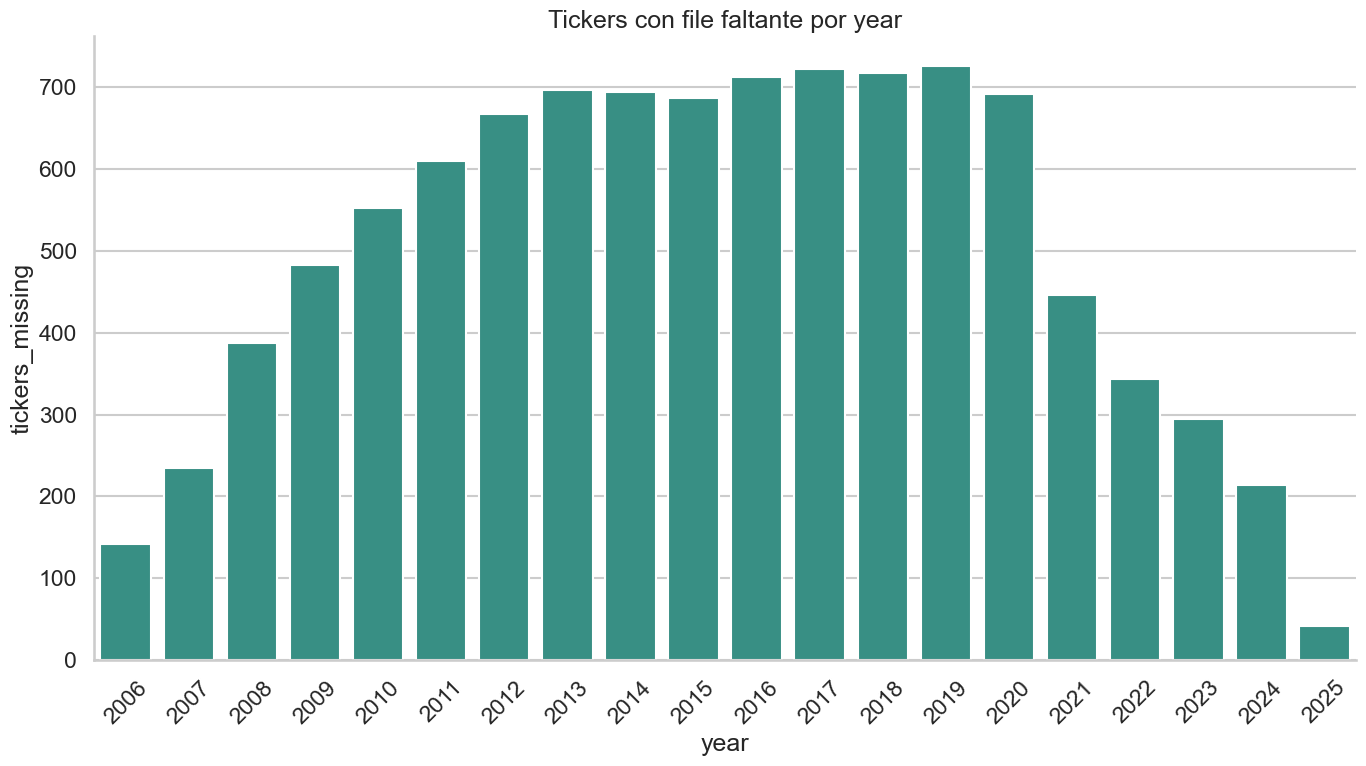

## Download tasks para Polygon

,task_key,ticker,year,date_from,date_to,download_reason,start_year_observed,end_year_observed,target_path
0,AAA|2008,AAA,2008,2008-01-01,2008-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2008\day_aggs_AAA_2008.parquet
1,AAA|2009,AAA,2009,2009-01-01,2009-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2009\day_aggs_AAA_2009.parquet
2,AAA|2010,AAA,2010,2010-01-01,2010-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2010\day_aggs_AAA_2010.parquet
3,AAA|2011,AAA,2011,2011-01-01,2011-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2011\day_aggs_AAA_2011.parquet
4,AAA|2012,AAA,2012,2012-01-01,2012-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2012\day_aggs_AAA_2012.parquet
5,AAA|2013,AAA,2013,2013-01-01,2013-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2013\day_aggs_AAA_2013.parquet
6,AAA|2014,AAA,2014,2014-01-01,2014-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2014\day_aggs_AAA_2014.parquet
7,AAA|2015,AAA,2015,2015-01-01,2015-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2015\day_aggs_AAA_2015.parquet
8,AAA|2016,AAA,2016,2016-01-01,2016-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2016\day_aggs_AAA_2016.parquet
9,AAA|2017,AAA,2017,2017-01-01,2017-12-31,missing_daily_ticker_year_file,2005,2026,D:\ohlcv_daily\ticker=AAA\year=2017\day_aggs_AAA_2017.parquet


C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\daily_v2_audit\daily_file_span_audit_full\daily_missing_ticker_year_download_tasks.parquet
C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\daily_v2_audit\daily_file_span_audit_full\daily_missing_ticker_year_download_tasks.csv


In [21]:
# ============================================================
# Auditoria estructural: ticker-year files faltantes
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

SPAN_AUDIT_DIR = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\daily_file_span_audit_full"
)

by_ticker = pd.read_parquet(SPAN_AUDIT_DIR / "daily_file_span_audit_by_ticker.parquet")
missing_years = pd.read_parquet(SPAN_AUDIT_DIR / "daily_file_span_audit_missing_years.parquet")

display(Markdown("## Resumen estructural ticker-year"))
display(pd.DataFrame([{
    "tickers_total": int(by_ticker["ticker"].nunique()),
    "contiguous_tickers": int(by_ticker["is_contiguous_span"].sum()),
    "non_contiguous_tickers": int((~by_ticker["is_contiguous_span"]).sum()),
    "pct_contiguous_tickers": round(100 * by_ticker["is_contiguous_span"].mean(), 4),
    "missing_year_rows": int(len(missing_years)),
}]))

# ------------------------------------------------------------
# Tickers con huecos estructurales
# ------------------------------------------------------------

broken = by_ticker[~by_ticker["is_contiguous_span"]].copy()
broken = broken.sort_values(
    ["missing_years_in_span_count", "start_year_observed", "ticker"],
    ascending=[False, True, True],
)

display(Markdown("## Top tickers con mas years faltantes dentro del span observado"))
display(
    broken[
        [
            "ticker",
            "start_year_observed",
            "end_year_observed",
            "unique_years_observed",
            "expected_years_in_span",
            "missing_years_in_span_count",
            "missing_years_in_span",
        ]
    ].head(5)
)

plt.figure(figsize=(14, 6))
sns.histplot(broken["missing_years_in_span_count"], bins=30, color="#e76f51")
plt.title("Distribucion de missing_years_in_span_count")
plt.xlabel("missing years in span")
plt.ylabel("tickers")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Exactamente que ticker-year falta
# ------------------------------------------------------------

display(Markdown("## Exactamente que ticker-year falta"))
display(missing_years.head(20))

plt.figure(figsize=(14, 8))
top_missing_years = (
    missing_years["missing_year"]
    .value_counts()
    .rename_axis("missing_year")
    .reset_index(name="tickers_missing")
    .sort_values("missing_year")
)
sns.barplot(data=top_missing_years, x="missing_year", y="tickers_missing", color="#2a9d8f")
plt.title("Tickers con file faltante por year")
plt.xlabel("year")
plt.ylabel("tickers_missing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Cola de descarga para Polygon: ticker-year faltantes
# ------------------------------------------------------------

download_tasks = missing_years.copy()
download_tasks["task_key"] = download_tasks["ticker"] + "|" + download_tasks["missing_year"].astype(str)
download_tasks["year"] = download_tasks["missing_year"].astype(int)
download_tasks["date_from"] = download_tasks["year"].astype(str) + "-01-01"
download_tasks["date_to"] = download_tasks["year"].astype(str) + "-12-31"
download_tasks["download_reason"] = "missing_daily_ticker_year_file"
download_tasks["target_path"] = download_tasks.apply(
    lambda r: rf"D:\ohlcv_daily\ticker={r['ticker']}\year={int(r['year'])}\day_aggs_{r['ticker']}_{int(r['year'])}.parquet",
    axis=1,
)

download_tasks = download_tasks[
    [
        "task_key",
        "ticker",
        "year",
        "date_from",
        "date_to",
        "download_reason",
        "start_year_observed",
        "end_year_observed",
        "target_path",
    ]
].sort_values(["ticker", "year"]).reset_index(drop=True)

display(Markdown("## Download tasks para Polygon"))
display(download_tasks.head(10))

OUT_TASKS = SPAN_AUDIT_DIR / "daily_missing_ticker_year_download_tasks.parquet"
OUT_TASKS_CSV = SPAN_AUDIT_DIR / "daily_missing_ticker_year_download_tasks.csv"

download_tasks.to_parquet(OUT_TASKS, index=False)
download_tasks.to_csv(OUT_TASKS_CSV, index=False)

print(OUT_TASKS)
print(OUT_TASKS_CSV)

## 57 no se movió nada tras la redescarga de los 57

In [22]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

PROBLEMATIC_57 = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\lt1b_missing_vs_universe_audit_full\lt1b_really_problematic_unexpected.parquet"
)

df57 = pd.read_parquet(PROBLEMATIC_57).copy()

# normalizacion minima
df57["ticker"] = df57["ticker"].astype(str).str.upper().str.strip()
tickers57 = sorted(df57["ticker"].dropna().unique().tolist())

display(Markdown("## 57 tickers realmente problemáticos"))
display(pd.DataFrame({"ticker": tickers57}))

print("count =", len(tickers57))
print("\nTradingView comma-separated:\n")
print(",".join(tickers57))

print("\nTradingView prefixed with NASDAQ/NYSE auto-style not forced:\n")
print("\n".join(tickers57))

print("\nPython list:\n")
print(tickers57)

## 57 tickers realmente problemáticos

,ticker
0,ADAM
1,ADCT
2,AHPA
3,ALTS
4,APXT
5,ARP
6,ASPC
7,AULT
8,BPAC
9,BTX


count = 57

TradingView comma-separated:

ADAM,ADCT,AHPA,ALTS,APXT,ARP,ASPC,AULT,BPAC,BTX,CALC,CAPN,CCRD,CELL,CGNT,CMPX,COOL,CSG,DSAC,ETD,FIEE,FLYX,GLAC,GLBL,GPAC,GRI,GRSH,GSD,HTB,ICU,LINK,MACQ,MAMA,MATV,MDXG,MLAC,MPAC,MTC,NRC,NXPL,PAAC,PAMT,PDYN,PRST,PV,RMG,ROI,RT,SISI,SLNG,SNDA,SOFO,SOL,TDAC,TEU,TLF,TRAK

TradingView prefixed with NASDAQ/NYSE auto-style not forced:

ADAM
ADCT
AHPA
ALTS
APXT
ARP
ASPC
AULT
BPAC
BTX
CALC
CAPN
CCRD
CELL
CGNT
CMPX
COOL
CSG
DSAC
ETD
FIEE
FLYX
GLAC
GLBL
GPAC
GRI
GRSH
GSD
HTB
ICU
LINK
MACQ
MAMA
MATV
MDXG
MLAC
MPAC
MTC
NRC
NXPL
PAAC
PAMT
PDYN
PRST
PV
RMG
ROI
RT
SISI
SLNG
SNDA
SOFO
SOL
TDAC
TEU
TLF
TRAK

Python list:

['ADAM', 'ADCT', 'AHPA', 'ALTS', 'APXT', 'ARP', 'ASPC', 'AULT', 'BPAC', 'BTX', 'CALC', 'CAPN', 'CCRD', 'CELL', 'CGNT', 'CMPX', 'COOL', 'CSG', 'DSAC', 'ETD', 'FIEE', 'FLYX', 'GLAC', 'GLBL', 'GPAC', 'GRI', 'GRSH', 'GSD', 'HTB', 'ICU', 'LINK', 'MACQ', 'MAMA', 'MATV', 'MDXG', 'MLAC', 'MPAC', 'MTC', 'NRC', 'NXPL', 'PAAC', 'PAMT', 'PDYN', 'PRST', 'PV',

In [23]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

PROBLEMATIC_57 = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\lt1b_missing_vs_universe_audit_full\lt1b_really_problematic_unexpected.parquet"
)

MISSING_AUDIT = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\daily_missing_years_vs_universe_calendar_full\daily_missing_years_vs_universe_calendar.parquet"
)

p57 = pd.read_parquet(PROBLEMATIC_57).copy()
ma = pd.read_parquet(MISSING_AUDIT).copy()

p57["ticker"] = p57["ticker"].astype(str).str.upper().str.strip()
ma["ticker"] = ma["ticker"].astype(str).str.upper().str.strip()

target = sorted(p57["ticker"].dropna().unique().tolist())

detail = (
    ma[
        ma["ticker"].isin(target)
        & ma["classification"].isin(["unexpected_missing", "unexpected_missing_calendar_unavailable"])
    ]
    .copy()
    .sort_values(["ticker", "missing_year"])
)

display(Markdown("## Columnas disponibles en missing audit"))
print(detail.columns.tolist())

preferred_cols = [
    "ticker",
    "missing_year",
    "classification",
    "reference_start_year",
    "reference_end_year",
    "start_year_observed",
    "end_year_observed",
    "reference_kind",
    "entity_id_count",
]
show_cols = [c for c in preferred_cols if c in detail.columns]

display(Markdown("## Years faltantes por ticker para los 57 problemáticos"))
display(detail[show_cols])

agg_map = {
    "missing_years": ("missing_year", lambda s: sorted(pd.Series(s).dropna().astype(int).unique().tolist())),
    "missing_years_count": ("missing_year", "nunique"),
}

for col in [
    "start_year_observed",
    "end_year_observed",
    "reference_start_year",
    "reference_end_year",
    "entity_id_count",
]:
    if col in detail.columns:
        agg_map[col] = (col, "min" if col != "end_year_observed" and col != "reference_end_year" else "max")

if "reference_kind" in detail.columns:
    agg_map["reference_kind"] = ("reference_kind", lambda s: sorted(pd.Series(s).dropna().astype(str).unique().tolist()))

by_ticker = (
    detail.groupby("ticker", dropna=False)
    .agg(**agg_map)
    .reset_index()
    .sort_values(["missing_years_count", "ticker"], ascending=[False, True])
)

display(Markdown("## Resumen por ticker"))
display(by_ticker)

print("Tickers problemáticos:", by_ticker["ticker"].nunique())
print("Rows missing ticker|year:", len(detail))

## Columnas disponibles en missing audit

['ticker', 'missing_year', 'start_year_observed', 'end_year_observed', 'universe_rows', 'entity_id_nunique', 'primary_exchange_nunique', 'list_date_min', 'delisted_utc_max', 'first_seen_date_min', 'last_seen_date_max', 'status_nunique', 'lifecycle_start_ref', 'lifecycle_end_ref', 'reference_kind', 'expected_year_start', 'expected_year_end', 'intersects_reference_window', 'expected_session_count_in_year', 'calendar_source', 'classification']


## Years faltantes por ticker para los 57 problemáticos

,ticker,missing_year,classification,start_year_observed,end_year_observed,reference_kind
6423,ADAM,2016,unexpected_missing,2005,2026,single_entity_ticker
6424,ADAM,2017,unexpected_missing,2005,2026,single_entity_ticker
6425,ADAM,2018,unexpected_missing,2005,2026,single_entity_ticker
6426,ADAM,2019,unexpected_missing,2005,2026,single_entity_ticker
6427,ADAM,2020,unexpected_missing,2005,2026,single_entity_ticker
6428,ADAM,2021,unexpected_missing,2005,2026,single_entity_ticker
6429,ADAM,2022,unexpected_missing,2005,2026,single_entity_ticker
6430,ADAM,2023,unexpected_missing,2005,2026,single_entity_ticker
6431,ADAM,2024,unexpected_missing,2005,2026,single_entity_ticker
6432,ADCT,2019,unexpected_missing,2005,2026,single_entity_ticker


## Resumen por ticker

,ticker,missing_years,missing_years_count,start_year_observed,end_year_observed,reference_kind
33,MATV,"[2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]",15,2005,2026,[single_entity_ticker]
12,CCRD,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]",13,2005,2025,[single_entity_ticker]
44,PV,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]",13,2005,2022,[single_entity_ticker]
19,ETD,"[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]",10,2009,2026,[single_entity_ticker]
0,ADAM,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",9,2005,2026,[single_entity_ticker]
28,HTB,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",9,2005,2026,[single_entity_ticker]
41,PAMT,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]",8,2012,2026,[single_entity_ticker]
45,RMG,"[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]",8,2008,2020,[single_entity_ticker]
56,TRAK,"[2016, 2017, 2018, 2019, 2020, 2021, 2022]",7,2005,2026,[single_entity_ticker]
11,CAPN,"[2018, 2019, 2020, 2021, 2022, 2023]",6,2014,2026,[single_entity_ticker]


Tickers problemáticos: 57
Rows missing ticker|year: 187


In [24]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

OUTDIR = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\problematic57_cross_1m_quotes_trades_full"
)

cmp = pd.read_parquet(OUTDIR / "problematic57_cross_1m_quotes_trades.parquet")
sig = pd.read_parquet(OUTDIR / "problematic57_cross_1m_quotes_trades_by_signature.parquet")

display(Markdown("## Resumen por firma de cobertura"))
display(sig)

display(Markdown("## Comparativa completa de los 57"))
display(cmp)

display(Markdown("## Casos sin 1m"))
display(cmp[~cmp["in_ohlcv_1m"].fillna(False)].copy())

display(Markdown("## Casos sin quotes"))
display(cmp[~cmp["in_quotes"].fillna(False)].copy())

display(Markdown("## Casos sin trades"))
display(cmp[~cmp["in_trades"].fillna(False)].copy())

## Resumen por firma de cobertura

,coverage_signature,tickers
0,1m|quotes|trades,57


## Comparativa completa de los 57

,ticker,missing_year_rows,unexpected_rows,unexpected_clean_rows,unexpected_ambiguous_rows,likely_valid_rows,classifications,lt1b_daily_gap_status,daily_missing_year_rows,daily_missing_years,daily_missing_year_min,daily_missing_year_max,start_year_observed,end_year_observed,unique_years_observed,expected_years_in_span,missing_years_in_span_count,missing_years_in_span,is_contiguous_span,in_ohlcv_1m,minute_year_min,minute_year_max,minute_years_count,minute_files_total,quotes_files_total,quotes_task_keys,quotes_roots_present,quotes_date_min,quotes_date_max,quotes_bytes_total,trades_files_total,trades_task_keys,trades_roots_present,trades_date_min,trades_date_max,trades_bytes_total,in_quotes,in_trades,coverage_signature
0,MATV,15,15,15,0,0,[unexpected_missing],REALLY_PROBLEMATIC_UNEXPECTED,15,"[2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]",2007,2021,2005,2026,7,22,15,"[2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]",False,True,2005,2026,7,62,1298,1298,C|D,2005-01-03,2026-03-06,164505885,1025,1025,C,2005-01-03,2026-03-06,50277260,True,True,1m|quotes|trades
1,CCRD,15,13,13,0,2,"[likely_valid_gap_outside_reference_window, unexpected_missing]",REALLY_PROBLEMATIC_UNEXPECTED,13,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]",2008,2020,2005,2025,6,21,15,"[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]",False,True,2005,2025,6,53,1072,1072,D,2005-01-03,2025-10-30,30560364,1072,1072,C,2005-01-03,2025-10-30,14877558,True,True,1m|quotes|trades
2,PV,13,13,13,0,0,[unexpected_missing],REALLY_PROBLEMATIC_UNEXPECTED,13,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]",2008,2020,2005,2022,5,18,13,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]",False,True,2005,2022,5,56,1137,1137,C|D,2005-01-03,2022-12-14,10752843,987,987,C,2005-01-03,2022-12-14,6674031,True,True,1m|quotes|trades
3,ETD,10,10,10,0,0,[unexpected_missing],REALLY_PROBLEMATIC_UNEXPECTED,10,"[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]",2011,2020,2009,2026,8,18,10,"[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]",False,True,2009,2026,8,68,1364,1364,C|D,2009-11-27,2026-03-06,172342407,1271,1271,C,2009-11-27,2026-03-06,52208629,True,True,1m|quotes|trades
4,ADAM,13,9,9,0,4,"[likely_valid_gap_outside_reference_window, unexpected_missing]",REALLY_PROBLEMATIC_UNEXPECTED,9,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2016,2024,2005,2026,9,22,13,"[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",False,True,2005,2026,9,81,1664,1664,D,2005-01-03,2026-03-06,64428811,1663,1663,C|D,2005-01-03,2026-03-06,18885031,True,True,1m|quotes|trades
5,HTB,13,9,9,0,4,"[likely_valid_gap_outside_reference_window, unexpected_missing]",REALLY_PROBLEMATIC_UNEXPECTED,9,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2016,2024,2005,2026,9,22,13,"[2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",False,True,2005,2026,9,92,1885,1885,C|D,2005-01-03,2026-03-06,32170491,1882,1882,C,2005-01-03,2026-03-06,16244387,True,True,1m|quotes|trades
6,PAMT,9,8,8,0,1,"[likely_valid_gap_outside_reference_window, unexpected_missing]",REALLY_PROBLEMATIC_UNEXPECTED,8,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]",2016,2023,2012,2026,6,15,9,"[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]",False,True,2012,2026,6,43,845,845,C|D,2012-03-22,2026-03-06,20548669,844,844,C,2012-03-22,2026-03-06,9328004,True,True,1m|quotes|trades
7,RMG,8,8,8,0,0,[unexpected_missing],REALLY_PROBLEMATIC_UNEXPECTED,8,"[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]",2011,2018,2008,2020,5,13,8,"[2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]",False,True,2008,2020,5,46,946,946,C|D,2008-01-25,2020-12-29,44125420,855,855,C,2008-01-25,2020-12-29,17514229,True,True,1m|quotes|trades
8,TRAK,7,7,7,0,0,[unexpected_missing],REALLY_PROBL

## Casos sin 1m

,ticker,missing_year_rows,unexpected_rows,unexpected_clean_rows,unexpected_ambiguous_rows,likely_valid_rows,classifications,lt1b_daily_gap_status,daily_missing_year_rows,daily_missing_years,daily_missing_year_min,daily_missing_year_max,start_year_observed,end_year_observed,unique_years_observed,expected_years_in_span,missing_years_in_span_count,missing_years_in_span,is_contiguous_span,in_ohlcv_1m,minute_year_min,minute_year_max,minute_years_count,minute_files_total,quotes_files_total,quotes_task_keys,quotes_roots_present,quotes_date_min,quotes_date_max,quotes_bytes_total,trades_files_total,trades_task_keys,trades_roots_present,trades_date_min,trades_date_max,trades_bytes_total,in_quotes,in_trades,coverage_signature


## Casos sin quotes

,ticker,missing_year_rows,unexpected_rows,unexpected_clean_rows,unexpected_ambiguous_rows,likely_valid_rows,classifications,lt1b_daily_gap_status,daily_missing_year_rows,daily_missing_years,daily_missing_year_min,daily_missing_year_max,start_year_observed,end_year_observed,unique_years_observed,expected_years_in_span,missing_years_in_span_count,missing_years_in_span,is_contiguous_span,in_ohlcv_1m,minute_year_min,minute_year_max,minute_years_count,minute_files_total,quotes_files_total,quotes_task_keys,quotes_roots_present,quotes_date_min,quotes_date_max,quotes_bytes_total,trades_files_total,trades_task_keys,trades_roots_present,trades_date_min,trades_date_max,trades_bytes_total,in_quotes,in_trades,coverage_signature


## Casos sin trades

,ticker,missing_year_rows,unexpected_rows,unexpected_clean_rows,unexpected_ambiguous_rows,likely_valid_rows,classifications,lt1b_daily_gap_status,daily_missing_year_rows,daily_missing_years,daily_missing_year_min,daily_missing_year_max,start_year_observed,end_year_observed,unique_years_observed,expected_years_in_span,missing_years_in_span_count,missing_years_in_span,is_contiguous_span,in_ohlcv_1m,minute_year_min,minute_year_max,minute_years_count,minute_files_total,quotes_files_total,quotes_task_keys,quotes_roots_present,quotes_date_min,quotes_date_max,quotes_bytes_total,trades_files_total,trades_task_keys,trades_roots_present,trades_date_min,trades_date_max,trades_bytes_total,in_quotes,in_trades,coverage_signature


In [25]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

OUTDIR = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\problematic57_cross_1m_quotes_trades_full"
)

cmp = pd.read_parquet(OUTDIR / "problematic57_cross_1m_quotes_trades.parquet").copy()

for c in ["quotes_date_min", "quotes_date_max", "trades_date_min", "trades_date_max"]:
    if c in cmp.columns:
        cmp[c] = pd.to_datetime(cmp[c], errors="coerce")

cmp["quotes_year_min"] = cmp["quotes_date_min"].dt.year
cmp["quotes_year_max"] = cmp["quotes_date_max"].dt.year
cmp["trades_year_min"] = cmp["trades_date_min"].dt.year
cmp["trades_year_max"] = cmp["trades_date_max"].dt.year

def years_inside_window(years, y0, y1):
    if not isinstance(years, (list, tuple)) or pd.isna(y0) or pd.isna(y1):
        return []
    return [y for y in years if int(y0) <= int(y) <= int(y1)]

cmp["missing_years_in_quotes_window"] = cmp.apply(
    lambda r: years_inside_window(r.get("daily_missing_years"), r.get("quotes_year_min"), r.get("quotes_year_max")),
    axis=1,
)
cmp["missing_years_in_trades_window"] = cmp.apply(
    lambda r: years_inside_window(r.get("daily_missing_years"), r.get("trades_year_min"), r.get("trades_year_max")),
    axis=1,
)
cmp["missing_years_in_1m_window"] = cmp.apply(
    lambda r: years_inside_window(r.get("daily_missing_years"), r.get("minute_year_min"), r.get("minute_year_max")),
    axis=1,
)

cmp["n_missing_in_quotes_window"] = cmp["missing_years_in_quotes_window"].apply(len)
cmp["n_missing_in_trades_window"] = cmp["missing_years_in_trades_window"].apply(len)
cmp["n_missing_in_1m_window"] = cmp["missing_years_in_1m_window"].apply(len)

display(Markdown("## Years faltantes de daily que caen dentro de las ventanas de otros universos"))
display(
    cmp[
        [
            "ticker",
            "daily_missing_years",
            "minute_year_min",
            "minute_year_max",
            "quotes_year_min",
            "quotes_year_max",
            "trades_year_min",
            "trades_year_max",
            "missing_years_in_1m_window",
            "missing_years_in_quotes_window",
            "missing_years_in_trades_window",
            "n_missing_in_1m_window",
            "n_missing_in_quotes_window",
            "n_missing_in_trades_window",
        ]
    ].sort_values(
        ["n_missing_in_1m_window", "n_missing_in_quotes_window", "n_missing_in_trades_window", "ticker"],
        ascending=[False, False, False, True],
    )
)

display(Markdown("## Casos donde los years faltantes de daily caen dentro de las tres ventanas"))
triple = cmp[
    (cmp["n_missing_in_1m_window"] > 0)
    & (cmp["n_missing_in_quotes_window"] > 0)
    & (cmp["n_missing_in_trades_window"] > 0)
].copy()

display(
    triple[
        [
            "ticker",
            "daily_missing_years",
            "missing_years_in_1m_window",
            "missing_years_in_quotes_window",
            "missing_years_in_trades_window",
        ]
    ].sort_values("ticker")
)

print("tickers con solape en las tres ventanas:", triple["ticker"].nunique())

## Years faltantes de daily que caen dentro de las ventanas de otros universos

,ticker,daily_missing_years,minute_year_min,minute_year_max,quotes_year_min,quotes_year_max,trades_year_min,trades_year_max,missing_years_in_1m_window,missing_years_in_quotes_window,missing_years_in_trades_window,n_missing_in_1m_window,n_missing_in_quotes_window,n_missing_in_trades_window
4,ADAM,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]",2005,2026,2005,2026,2005,2026,[],[],[],0,0,0
36,ADCT,[2019],2005,2026,2005,2026,2005,2026,[],[],[],0,0,0
22,AHPA,"[2019, 2020]",2017,2022,2017,2022,2017,2022,[],[],[],0,0,0
37,ALTS,[2023],2014,2026,2014,2026,2014,2026,[],[],[],0,0,0
13,APXT,"[2022, 2023, 2024]",2019,2026,2019,2026,2019,2026,[],[],[],0,0,0
38,ARP,[2011],2005,2026,2005,2026,2005,2026,[],[],[],0,0,0
23,ASPC,"[2023, 2024]",2021,2026,2021,2026,2021,2026,[],[],[],0,0,0
11,AULT,"[2019, 2020, 2021, 2022]",2005,2024,2005,2024,2005,2024,[],[],[],0,0,0
24,BPAC,"[2024, 2025]",2022,2026,2022,2026,2022,2026,[],[],[],0,0,0
39,BTX,[2009],2005,2026,2005,2026,2005,2026,[],[],[],0,0,0


## Casos donde los years faltantes de daily caen dentro de las tres ventanas

,ticker,daily_missing_years,missing_years_in_1m_window,missing_years_in_quotes_window,missing_years_in_trades_window


tickers con solape en las tres ventanas: 0


In [26]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

OUTDIR = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\problematic57_per_day_cross_full"
)

per_ticker = pd.read_parquet(OUTDIR / "problematic57_per_ticker_summary.parquet")
per_ticker_year = pd.read_parquet(OUTDIR / "problematic57_per_ticker_year_summary.parquet")

display(Markdown("## Peores tickers vs daily"))
display(
    per_ticker[
        [
            "ticker",
            "daily_days",
            "minute_days",
            "quotes_days",
            "trades_days",
            "daily_missing_vs_1m_count",
            "daily_missing_vs_quotes_count",
            "daily_missing_vs_trades_count",
            "last_daily_date",
            "last_1m_date",
            "last_quotes_date",
            "last_trades_date",
            "last_dates_match_all",
            "daily_missing_vs_1m",
            "daily_missing_vs_quotes",
            "daily_missing_vs_trades",
        ]
    ].head(2).T
)

display(Markdown("## Peores ticker-year vs daily"))
display(
    per_ticker_year[
        [
            "ticker",
            "year",
            "daily_days",
            "minute_days",
            "quotes_days",
            "trades_days",
            "daily_missing_vs_1m_count",
            "daily_missing_vs_quotes_count",
            "daily_missing_vs_trades_count",
            "last_daily_date",
            "last_1m_date",
            "last_quotes_date",
            "last_trades_date",
            "last_dates_match_all",
        ]
    ].head(5).T
)

## Peores tickers vs daily

,0,1
ticker,SOL,MTC
daily_days,4554,1817
minute_days,4642,1864
quotes_days,4554,1825
trades_days,4552,1818
daily_missing_vs_1m_count,88,47
daily_missing_vs_quotes_count,0,8
daily_missing_vs_trades_count,0,1
last_daily_date,2025-12-12,2026-03-06
last_1m_date,2025-12-13,2026-03-09


## Peores ticker-year vs daily

,0,1,2,3,4
ticker,PDYN,AULT,SOL,GRI,GRI
year,2025,2023,2021,2024,2025
daily_days,250,250,252,252,250
minute_days,269,268,268,266,264
quotes_days,250,250,252,252,250
trades_days,250,250,252,252,250
daily_missing_vs_1m_count,19,18,16,14,14
daily_missing_vs_quotes_count,0,0,0,0,0
daily_missing_vs_trades_count,0,0,0,0,0
last_daily_date,2025-12-31,2023-12-29,2021-12-31,2024-12-31,2025-12-31


In [31]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
import ipywidgets as widgets

OUTDIR = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\problematic57_per_day_cross_full"
)

panel = pd.read_parquet(OUTDIR / "problematic57_per_day_panel.parquet").copy()
panel["date"] = pd.to_datetime(panel["date"], errors="coerce").dt.normalize()
panel = panel.dropna(subset=["ticker", "date"]).copy()

UNIVERSES = [
    ("in_1m", "1m", "#0066CC"),
    ("in_trades", "trades", "#169B45"),
    ("in_quotes", "quotes", "#F57C00"),
    ("in_daily", "daily", "#8B1E1E"),
]

tickers57 = sorted(panel["ticker"].astype(str).unique().tolist())

def contiguous_segments(dates: pd.Series, max_gap_days: int = 3):
    ds = pd.Series(pd.to_datetime(dates, errors="coerce").dropna().sort_values().unique())
    if ds.empty:
        return []

    out = []
    start = ds.iloc[0]
    prev = ds.iloc[0]

    for d in ds.iloc[1:]:
        if (d - prev).days <= max_gap_days:
            prev = d
            continue
        out.append((start, prev))
        start = d
        prev = d

    out.append((start, prev))
    return out

segments_by_ticker = {}
for ticker in tickers57:
    sub = panel[panel["ticker"] == ticker].copy()
    info = {}
    for col, label, color in UNIVERSES:
        dates = sub.loc[sub[col].fillna(False).astype(bool), "date"]
        info[label] = {
            "color": color,
            "segments": contiguous_segments(dates, max_gap_days=3),
            "days": int(pd.Series(dates).nunique()),
            "first": pd.Series(dates).min() if len(dates) else pd.NaT,
            "last": pd.Series(dates).max() if len(dates) else pd.NaT,
        }
    segments_by_ticker[ticker] = info

print("tickers =", len(tickers57))
print("ejemplo =", tickers57[:10])

def plot_ticker_coverage(ticker: str):
    info = segments_by_ticker[ticker]

    fig, ax = plt.subplots(figsize=(18, 5.6), constrained_layout=True)

    y_positions = {
        "1m": 30,
        "trades": 20,
        "quotes": 10,
        "daily": 0,
    }
    bar_h = 7.5

    first_dates = [info[k]["first"] for k in info if pd.notna(info[k]["first"])]
    last_dates = [info[k]["last"] for k in info if pd.notna(info[k]["last"])]

    xmin = min(first_dates) - pd.Timedelta(days=30) if first_dates else pd.Timestamp("2005-01-01")
    xmax = max(last_dates) + pd.Timedelta(days=30) if last_dates else pd.Timestamp("2026-12-31")

    # barras
    for label in ["1m", "trades", "quotes", "daily"]:
        meta = info[label]
        bars = []
        for start, end in meta["segments"]:
            x0 = mdates.date2num(start)
            width = mdates.date2num(end + pd.Timedelta(days=1)) - x0
            bars.append((x0, width))

        if bars:
            ax.broken_barh(
                bars,
                (y_positions[label], bar_h),
                facecolors=meta["color"],
                edgecolors=meta["color"],
                linewidth=0,
                alpha=1.0,
                zorder=3,
            )

        # etiqueta izquierda en coordenadas del eje Y, no en fechas
        ax.text(
            -0.06,
            y_positions[label] + bar_h / 2,
            f"{label}  days={meta['days']}",
            transform=ax.get_yaxis_transform(),
            va="center",
            ha="right",
            fontsize=11,
            fontweight="bold",
            color=meta["color"],
            clip_on=False,
        )

    # formato ejes
    ax.set_xlim(mdates.date2num(xmin), mdates.date2num(xmax))
    ax.set_ylim(-2, 40)
    ax.set_yticks([30 + bar_h / 2, 20 + bar_h / 2, 10 + bar_h / 2, 0 + bar_h / 2])
    ax.set_yticklabels(["1m", "trades", "quotes", "daily"], fontsize=12)
    ax.tick_params(axis="y", length=0)

    ax.xaxis_date()
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)

    ax.grid(axis="x", alpha=0.20, linewidth=0.8, zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # título en dos líneas
    title = f"{ticker}"
    subtitle = (
        f"1m={info['1m']['days']}   "
        f"trades={info['trades']['days']}   "
        f"quotes={info['quotes']['days']}   "
        f"daily={info['daily']['days']}"
    )
    ax.set_title(title, fontsize=22, fontweight="bold", pad=18)
    ax.text(
        0.5, 1.02, subtitle,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=14,
        color="#333333",
    )

    plt.show()

ticker_dd = widgets.Dropdown(
    options=tickers57,
    description="Ticker",
    layout=widgets.Layout(width="320px")
)

out = widgets.interactive_output(plot_ticker_coverage, {"ticker": ticker_dd})
display(ticker_dd, out)



tickers = 57
ejemplo = ['ADAM', 'ADCT', 'AHPA', 'ALTS', 'APXT', 'ARP', 'ASPC', 'AULT', 'BPAC', 'BTX']


Dropdown(description='Ticker', layout=Layout(width='320px'), options=('ADAM', 'ADCT', 'AHPA', 'ALTS', 'APXT', …

Output()

Lo que propongo para daily, leyendo esos cuatro artefactos, es esto:

- daily tiene el mismo ruido estructural conocido de schema en ticker
- el notebook ya avanzó más que 1m porque abrió vw en v020 y lo refinó en v030
- así que el cierre bueno de daily no es reabrir todo, sino convertir v030 en decisión operativa

La decisión que yo probaría en una celda es:

- HARD_FAIL -> cuarentena
- SOFT_FAIL con solo schema -> rescate
- SOFT_FAIL con vw_subtype = minor -> rescate
- SOFT_FAIL con vw_subtype = material -> rescate con flag
- SOFT_FAIL con vw_subtype = severe -> revisión separada
- luego mirar dónde caen exactamente los 57

In [28]:
# ============================================================
# Cierre operativo de daily: rescate vs cuarentena
# No modifica lógica previa; solo deriva una decisión operativa
# a partir del estado ya cargado en el notebook.
# Requiere cur_030_v3 si ya existe; si no, usa cur_020.
# Además cruza robustamente el subconjunto PROBLEMATIC_57.
# ============================================================

from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import re

base_df = None
if "cur_030_v3" in globals():
    base_df = cur_030_v3.copy()
    source_label = "v030"
elif "cur_020" in globals():
    base_df = cur_020.copy()
    source_label = "v020"
elif "events" in globals():
    base_df = events.copy()
    source_label = "events"
else:
    raise RuntimeError("No encuentro DataFrame base: cur_030_v3 / cur_020 / events")

df = base_df.copy()

def ensure_list_col(frame: pd.DataFrame, src: str, dst: str) -> pd.DataFrame:
    if dst not in frame.columns:
        if src in frame.columns:
            frame[dst] = frame[src].map(parse_listish)
        else:
            frame[dst] = [[] for _ in range(len(frame))]
    return frame

def robust_read_problematic_57(path):
    last_exc = None

    encodings = ["utf-8", "utf-8-sig", "cp1252", "latin-1"]
    seps = [",", ";", "\t", "|"]

    # intento normal con varios separadores/encodings
    for enc in encodings:
        for sep in seps:
            try:
                tmp = pd.read_csv(path, encoding=enc, sep=sep)
                tmp.columns = [str(c).strip().lower() for c in tmp.columns]
                if "ticker" in tmp.columns:
                    return tmp, enc, f"read_csv sep={repr(sep)}"
            except Exception as exc:
                last_exc = exc

    # intento con engine python
    for enc in encodings:
        for sep in seps:
            try:
                tmp = pd.read_csv(path, encoding=enc, sep=sep, engine="python")
                tmp.columns = [str(c).strip().lower() for c in tmp.columns]
                if "ticker" in tmp.columns:
                    return tmp, enc, f"read_csv(engine=python) sep={repr(sep)}"
            except Exception as exc:
                last_exc = exc

    # fallback: leer texto y extraer tickers línea a línea
    text = None
    used_encoding = None
    for enc in encodings:
        try:
            with open(path, "r", encoding=enc, errors="replace") as f:
                text = f.read()
            used_encoding = enc
            break
        except Exception as exc:
            last_exc = exc

    if text is None:
        raise last_exc if last_exc is not None else RuntimeError("No se pudo leer PROBLEMATIC_57")

    lines = [line.strip() for line in text.splitlines() if str(line).strip()]
    extracted = []

    # patrón permisivo de ticker
    ticker_pat = re.compile(r"\b[A-Z][A-Z0-9.\-]{0,9}\b")

    for line in lines:
        upper = line.upper()

        # saltar cabeceras obvias
        if "TICKER" in upper and len(upper.split()) <= 6:
            continue

        # intentar columnas separadas
        parts = re.split(r"[,\t;|]+", line)
        parts = [p.strip() for p in parts if p.strip()]

        found = None

        # si la primera columna parece ticker, usarla
        if parts:
            cand = parts[0].upper()
            if re.fullmatch(r"[A-Z][A-Z0-9.\-]{0,9}", cand):
                found = cand

        # si no, buscar patrón en toda la línea
        if found is None:
            m = ticker_pat.search(upper)
            if m:
                found = m.group(0)

        if found is not None:
            extracted.append(found)

    extracted = sorted(set(extracted))
    tmp = pd.DataFrame({"ticker": extracted})
    return tmp, used_encoding, "fallback_line_parser"

df = ensure_list_col(df, "issues", "issues_list")
df = ensure_list_col(df, "warns", "warns_list")

schema_warns = {"dataset_read_incompatible_schema", "schema_merge_conflict_ticker_encoding"}
df["has_schema_warn"] = df["warns_list"].map(lambda xs: bool(schema_warns & set(xs)))
df["has_vw_warn"] = df["warns_list"].map(lambda xs: "vw_outside_range_rows" in set(xs))

if "m.vw_outside_range_subtype" not in df.columns:
    df["m.vw_outside_range_subtype"] = np.where(
        df["has_vw_warn"], "unclassified_vw", ""
    )

df["daily_operational_decision"] = np.select(
    [
        df["severity"].astype(str).eq("HARD_FAIL"),
        df["severity"].astype(str).eq("SOFT_FAIL") & df["has_schema_warn"] & ~df["has_vw_warn"],
        df["severity"].astype(str).eq("SOFT_FAIL") & df["has_vw_warn"] & df["m.vw_outside_range_subtype"].astype(str).eq("minor"),
        df["severity"].astype(str).eq("SOFT_FAIL") & df["has_vw_warn"] & df["m.vw_outside_range_subtype"].astype(str).eq("material"),
        df["severity"].astype(str).eq("SOFT_FAIL") & df["has_vw_warn"] & df["m.vw_outside_range_subtype"].astype(str).eq("severe"),
        df["severity"].astype(str).eq("SOFT_FAIL") & df["has_vw_warn"],
    ],
    [
        "QUARANTINE_HARD_FAIL",
        "RESCUE_SCHEMA_ONLY",
        "RESCUE_VW_MINOR",
        "RESCUE_VW_MATERIAL",
        "REVIEW_VW_SEVERE",
        "REVIEW_VW_UNCLASSIFIED",
    ],
    default="OTHER"
)

display(Markdown(f"## Cierre operativo propuesto para daily desde `{source_label}`"))

decision_summary = (
    df.groupby("daily_operational_decision")
    .size()
    .rename("files")
    .reset_index()
    .sort_values("files", ascending=False)
)
decision_summary["pct"] = 100.0 * decision_summary["files"] / max(len(df), 1)
display(decision_summary)

ticker_summary = (
    df.groupby(["ticker", "daily_operational_decision"])
    .size()
    .rename("files")
    .reset_index()
    .sort_values(["files", "ticker"], ascending=[False, True])
)
display(ticker_summary.head(50))

# ============================================================
# Cruce robusto con PROBLEMATIC_57
# ============================================================

if "PROBLEMATIC_57" in globals():
    try:
        prob57, used_encoding, read_mode = robust_read_problematic_57(PROBLEMATIC_57)
        prob57.columns = [str(c).strip().lower() for c in prob57.columns]

        display(Markdown("## Corte específico sobre los 57"))
        display(Markdown(f"Encoding usado para `PROBLEMATIC_57`: `{used_encoding}`"))
        display(Markdown(f"Modo de lectura: `{read_mode}`"))

        if "ticker" not in prob57.columns:
            display(Markdown(f"Columnas detectadas: `{list(prob57.columns)}`"))
            raise ValueError("PROBLEMATIC_57 no tiene columna `ticker`")

        s57 = {str(x).strip().upper() for x in prob57["ticker"].dropna() if str(x).strip()}
        df57 = df[df["ticker"].astype(str).str.upper().isin(s57)].copy()

        display(pd.DataFrame([{
            "tickers_detectados_en_archivo": int(len(s57)),
            "rows_en_subset_cruzado": int(len(df57)),
            "tickers_en_subset_cruzado": int(df57["ticker"].nunique()) if "ticker" in df57.columns else 0,
        }]))

        summary57 = (
            df57.groupby("daily_operational_decision")
            .size()
            .rename("files")
            .reset_index()
            .sort_values("files", ascending=False)
        )
        if not summary57.empty:
            summary57["pct_of_57_subset"] = 100.0 * summary57["files"] / max(len(df57), 1)

        display(summary57)

        detail_cols = [
            c for c in [
                "ticker",
                "year",
                "severity",
                "daily_operational_decision",
                "m.vw_outside_range_subtype",
                "m.vw_outside_range_rows",
                "m.vw_outside_range_ratio_pct",
                "file",
            ]
            if c in df57.columns
        ]
        display(
            df57[detail_cols]
            .sort_values(
                [c for c in ["daily_operational_decision", "ticker", "year"] if c in df57.columns]
            )
            .head(100)
        )

    except Exception as exc:
        display(Markdown(f"**No se pudo cruzar PROBLEMATIC_57**: `{exc}`"))
else:
    display(Markdown("`PROBLEMATIC_57` no está definido en este notebook."))

## Cierre operativo propuesto para daily desde `v030`

,daily_operational_decision,files,pct
1,RESCUE_SCHEMA_ONLY,4050,81.0
0,QUARANTINE_HARD_FAIL,950,19.0


,ticker,daily_operational_decision,files
0,A,RESCUE_SCHEMA_ONLY,3
1,AA,RESCUE_SCHEMA_ONLY,3
2,AAA,RESCUE_SCHEMA_ONLY,3
9,AAGR,QUARANTINE_HARD_FAIL,3
10,AAL,RESCUE_SCHEMA_ONLY,3
20,AAON,RESCUE_SCHEMA_ONLY,3
21,AAP,RESCUE_SCHEMA_ONLY,3
26,AAT,RESCUE_SCHEMA_ONLY,3
27,AATC,RESCUE_SCHEMA_ONLY,3
30,AB,RESCUE_SCHEMA_ONLY,3


## Corte específico sobre los 57

Encoding usado para `PROBLEMATIC_57`: `utf-8`

Modo de lectura: `fallback_line_parser`

,tickers_detectados_en_archivo,rows_en_subset_cruzado,tickers_en_subset_cruzado
0,26,6,3


,daily_operational_decision,files,pct_of_57_subset
0,RESCUE_SCHEMA_ONLY,6,100.0


,ticker,year,severity,daily_operational_decision,m.vw_outside_range_subtype,m.vw_outside_range_rows,m.vw_outside_range_ratio_pct,file
271,ADAM,2025,SOFT_FAIL,RESCUE_SCHEMA_ONLY,NaN,0.0,0.0,D:\ohlcv_daily\ticker=ADAM\year=2025\day_aggs_ADAM_2025.parquet
272,ADAM,2026,SOFT_FAIL,RESCUE_SCHEMA_ONLY,NaN,0.0,0.0,D:\ohlcv_daily\ticker=ADAM\year=2026\day_aggs_ADAM_2026.parquet
2648,BPAC,2026,SOFT_FAIL,RESCUE_SCHEMA_ONLY,material,3.0,15.0,D:\ohlcv_daily\ticker=BPAC\year=2026\day_aggs_BPAC_2026.parquet
4997,D,2024,SOFT_FAIL,RESCUE_SCHEMA_ONLY,NaN,0.0,0.0,D:\ohlcv_daily\ticker=D\year=2024\day_aggs_D_2024.parquet
4998,D,2025,SOFT_FAIL,RESCUE_SCHEMA_ONLY,NaN,0.0,0.0,D:\ohlcv_daily\ticker=D\year=2025\day_aggs_D_2025.parquet
4999,D,2026,SOFT_FAIL,RESCUE_SCHEMA_ONLY,NaN,0.0,0.0,D:\ohlcv_daily\ticker=D\year=2026\day_aggs_D_2026.parquet


In [29]:
# ============================================================
# CIERRE FINAL DAILY
# Objetivo:
# 1. Convertir el ruido estructural en bucket conocido
# 2. Reclasificar vw usando v030
# 3. Sacar a los 57 del bloqueo global
# 4. Separar:
#    - likely_valid_gap_outside_reference_window
#    - real_daily_missing_to_review
# No modifica celdas previas; solo resume decisión operativa.
# ============================================================

from pathlib import Path
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import ast

display(Markdown("## Cierre final operativo de `daily`"))

# ------------------------------------------------------------
# 1) Base operativa desde v030 si existe
# ------------------------------------------------------------
if "cur_030_v3" in globals():
    base = cur_030_v3.copy()
    base_label = "v030"
elif "cur_020" in globals():
    base = cur_020.copy()
    base_label = "v020"
elif "events" in globals():
    base = events.copy()
    base_label = "events"
else:
    raise RuntimeError("No encuentro base diaria: cur_030_v3 / cur_020 / events")

def ensure_list_col(frame: pd.DataFrame, src: str, dst: str) -> pd.DataFrame:
    if dst not in frame.columns:
        if src in frame.columns:
            frame[dst] = frame[src].map(parse_listish)
        else:
            frame[dst] = [[] for _ in range(len(frame))]
    return frame

base = ensure_list_col(base, "issues", "issues_list")
base = ensure_list_col(base, "warns", "warns_list")

schema_warns = {"dataset_read_incompatible_schema", "schema_merge_conflict_ticker_encoding"}
base["has_schema_warn"] = base["warns_list"].map(lambda xs: bool(schema_warns & set(xs)))
base["has_vw_issue"] = base["issues_list"].map(lambda xs: "vw_outside_range_rows" in set(xs))
base["has_price_issue"] = base["issues_list"].map(lambda xs: "negative_or_zero_ohlc_rows" in set(xs))
base["has_parse_issue"] = base["issues_list"].map(lambda xs: "all_rows_invalid_after_parse" in set(xs))

if "m.vw_outside_range_subtype" not in base.columns:
    base["m.vw_outside_range_subtype"] = np.where(base["has_vw_issue"], "unclassified_vw", "")

# ------------------------------------------------------------
# 2) Decisión operativa principal de daily
# ------------------------------------------------------------
base["daily_final_decision"] = np.select(
    [
        base["severity"].astype(str).eq("HARD_FAIL") & base["has_parse_issue"],
        base["severity"].astype(str).eq("HARD_FAIL") & base["has_price_issue"],
        base["severity"].astype(str).eq("HARD_FAIL") & base["has_vw_issue"] & base["m.vw_outside_range_subtype"].astype(str).eq("severe"),
        base["severity"].astype(str).eq("HARD_FAIL") & base["has_vw_issue"] & base["m.vw_outside_range_subtype"].astype(str).eq("material"),
        base["severity"].astype(str).eq("HARD_FAIL") & base["has_vw_issue"] & base["m.vw_outside_range_subtype"].astype(str).eq("minor"),
        base["severity"].astype(str).eq("SOFT_FAIL") & base["has_schema_warn"] & ~base["has_vw_issue"],
        base["severity"].astype(str).eq("SOFT_FAIL") & base["has_vw_issue"] & base["m.vw_outside_range_subtype"].astype(str).eq("minor"),
        base["severity"].astype(str).eq("SOFT_FAIL") & base["has_vw_issue"] & base["m.vw_outside_range_subtype"].astype(str).eq("material"),
        base["severity"].astype(str).eq("SOFT_FAIL") & base["has_vw_issue"] & base["m.vw_outside_range_subtype"].astype(str).eq("severe"),
        base["severity"].astype(str).eq("PASS"),
    ],
    [
        "QUARANTINE_PARSE_INVALID",
        "QUARANTINE_PRICE_INVALID",
        "REVIEW_VW_SEVERE",
        "RESCUE_VW_MATERIAL",
        "RESCUE_VW_MINOR",
        "RESCUE_SCHEMA_ONLY",
        "RESCUE_VW_MINOR",
        "RESCUE_VW_MATERIAL",
        "REVIEW_VW_SEVERE",
        "PASS",
    ],
    default="REVIEW_OTHER"
)

decision_summary = (
    base.groupby("daily_final_decision")
    .size()
    .rename("files")
    .reset_index()
    .sort_values("files", ascending=False)
)
decision_summary["pct_of_base"] = 100.0 * decision_summary["files"] / max(len(base), 1)

display(Markdown(f"### 1. Decisión operativa desde `{base_label}`"))
display(decision_summary)

display(pd.DataFrame([{
    "rows_base": int(len(base)),
    "rescue_rows": int(base["daily_final_decision"].isin(["RESCUE_SCHEMA_ONLY", "RESCUE_VW_MINOR", "RESCUE_VW_MATERIAL", "PASS"]).sum()),
    "review_rows": int(base["daily_final_decision"].isin(["REVIEW_VW_SEVERE", "REVIEW_OTHER"]).sum()),
    "quarantine_rows": int(base["daily_final_decision"].isin(["QUARANTINE_PARSE_INVALID", "QUARANTINE_PRICE_INVALID"]).sum()),
}]))

# ------------------------------------------------------------
# 3) Leer el análisis cruzado de los 57
# ------------------------------------------------------------
OUTDIR_57_CROSS = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\problematic57_cross_1m_quotes_trades_full"
)
OUTDIR_57_DAY = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\problematic57_per_day_cross_full"
)

cmp57 = pd.read_parquet(OUTDIR_57_CROSS / "problematic57_cross_1m_quotes_trades.parquet").copy()
per_ticker57 = pd.read_parquet(OUTDIR_57_DAY / "problematic57_per_ticker_summary.parquet").copy()
per_ticker_year57 = pd.read_parquet(OUTDIR_57_DAY / "problematic57_per_ticker_year_summary.parquet").copy()

# ------------------------------------------------------------
# 4) Clasificación final de los 57
# Regla:
# - si classifications contiene likely_valid_gap_outside_reference_window
#   y además NO hay solape en las tres ventanas => likely_valid_gap_outside_reference_window
# - el resto => real_daily_missing_to_review
# ------------------------------------------------------------
def has_likely_valid(classifications):
    if isinstance(classifications, str):
        s = classifications.strip()
        if not s:
            return False
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple, set)):
                return "likely_valid_gap_outside_reference_window" in set(map(str, parsed))
        except Exception:
            return "likely_valid_gap_outside_reference_window" in s

    if isinstance(classifications, (list, tuple, set)):
        return "likely_valid_gap_outside_reference_window" in set(map(str, classifications))

    return False

def years_inside_window(years, y0, y1):
    if not isinstance(years, (list, tuple)) or pd.isna(y0) or pd.isna(y1):
        return []
    return [y for y in years if int(y0) <= int(y) <= int(y1)]

for c in ["quotes_date_min", "quotes_date_max", "trades_date_min", "trades_date_max"]:
    if c in cmp57.columns:
        cmp57[c] = pd.to_datetime(cmp57[c], errors="coerce")

cmp57["quotes_year_min"] = cmp57["quotes_date_min"].dt.year if "quotes_date_min" in cmp57.columns else np.nan
cmp57["quotes_year_max"] = cmp57["quotes_date_max"].dt.year if "quotes_date_max" in cmp57.columns else np.nan
cmp57["trades_year_min"] = cmp57["trades_date_min"].dt.year if "trades_date_min" in cmp57.columns else np.nan
cmp57["trades_year_max"] = cmp57["trades_date_max"].dt.year if "trades_date_max" in cmp57.columns else np.nan

cmp57["missing_years_in_quotes_window"] = cmp57.apply(
    lambda r: years_inside_window(r.get("daily_missing_years"), r.get("quotes_year_min"), r.get("quotes_year_max")),
    axis=1,
)
cmp57["missing_years_in_trades_window"] = cmp57.apply(
    lambda r: years_inside_window(r.get("daily_missing_years"), r.get("trades_year_min"), r.get("trades_year_max")),
    axis=1,
)
cmp57["missing_years_in_1m_window"] = cmp57.apply(
    lambda r: years_inside_window(r.get("daily_missing_years"), r.get("minute_year_min"), r.get("minute_year_max")),
    axis=1,
)

cmp57["n_missing_in_quotes_window"] = cmp57["missing_years_in_quotes_window"].apply(len)
cmp57["n_missing_in_trades_window"] = cmp57["missing_years_in_trades_window"].apply(len)
cmp57["n_missing_in_1m_window"] = cmp57["missing_years_in_1m_window"].apply(len)

cmp57["has_likely_valid_gap_flag"] = cmp57["classifications"].apply(has_likely_valid)
cmp57["has_triple_window_overlap"] = (
    (cmp57["n_missing_in_1m_window"] > 0)
    & (cmp57["n_missing_in_quotes_window"] > 0)
    & (cmp57["n_missing_in_trades_window"] > 0)
)

cmp57["problematic57_final_decision"] = np.where(
    cmp57["has_likely_valid_gap_flag"] & ~cmp57["has_triple_window_overlap"],
    "LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW",
    "REAL_DAILY_MISSING_TO_REVIEW"
)

display(Markdown("### 2. Decisión final sobre los 57"))
summary57 = (
    cmp57.groupby("problematic57_final_decision")
    .size()
    .rename("tickers")
    .reset_index()
    .sort_values("tickers", ascending=False)
)
summary57["pct_of_57"] = 100.0 * summary57["tickers"] / max(len(cmp57), 1)
display(summary57)

display(Markdown("### 3. Tickers de los 57 que siguen en revisión real"))
review57 = cmp57[cmp57["problematic57_final_decision"] == "REAL_DAILY_MISSING_TO_REVIEW"].copy()
display(
    review57[
        [
            c for c in [
                "ticker",
                "daily_missing_years",
                "missing_years_in_1m_window",
                "missing_years_in_quotes_window",
                "missing_years_in_trades_window",
                "classifications",
            ] if c in review57.columns
        ]
    ].sort_values("ticker")
)

display(Markdown("### 4. Tickers de los 57 que se desatascan"))
valid57 = cmp57[cmp57["problematic57_final_decision"] == "LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW"].copy()
display(
    valid57[
        [
            c for c in [
                "ticker",
                "daily_missing_years",
                "classifications",
                "n_missing_in_1m_window",
                "n_missing_in_quotes_window",
                "n_missing_in_trades_window",
            ] if c in valid57.columns
        ]
    ].sort_values("ticker")
)

# ------------------------------------------------------------
# 5) Resumen ejecutivo final
# ------------------------------------------------------------
display(Markdown("### 5. Lectura ejecutiva final"))

executive = pd.DataFrame([{
    "base_label": base_label,
    "daily_problem_core": "vw_outside_range_rows",
    "schema_problem_known": True,
    "dominant_hard_should_not_block_globally": True,
    "problematic57_total": int(len(cmp57)),
    "problematic57_likely_valid": int((cmp57["problematic57_final_decision"] == "LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW").sum()),
    "problematic57_real_review": int((cmp57["problematic57_final_decision"] == "REAL_DAILY_MISSING_TO_REVIEW").sum()),
    "triple_window_overlap_tickers": int(cmp57["has_triple_window_overlap"].sum()),
}])
display(executive)

display(Markdown(
    """
**Conclusión operativa propuesta para `daily`:**
- tratar el warning estructural de schema como bucket conocido
- rescatar `schema_only`
- rescatar `vw minor`
- rescatar `vw material` con flag
- revisar aparte `vw severe`
- mantener en cuarentena solo `parse_invalid` y `price_invalid`
- sacar del bloqueo global todos los `57` clasificados como `LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW`
"""
))

## Cierre final operativo de `daily`

### 1. Decisión operativa desde `v030`

,daily_final_decision,files,pct_of_base
2,RESCUE_SCHEMA_ONLY,4050,81.00
3,REVIEW_OTHER,932,18.64
1,QUARANTINE_PRICE_INVALID,17,0.34
0,QUARANTINE_PARSE_INVALID,1,0.02


,rows_base,rescue_rows,review_rows,quarantine_rows
0,5000,4050,932,18


### 2. Decisión final sobre los 57

...

### 4. Tickers de los 57 que se desatascan

,ticker,daily_missing_years,classifications,n_missing_in_1m_window,n_missing_in_quotes_window,n_missing_in_trades_window


### 5. Lectura ejecutiva final

,base_label,daily_problem_core,schema_problem_known,dominant_hard_should_not_block_globally,problematic57_total,problematic57_likely_valid,problematic57_real_review,triple_window_overlap_tickers
0,v030,vw_outside_range_rows,True,True,57,0,57,0



**Conclusión operativa propuesta para `daily`:**
- tratar el warning estructural de schema como bucket conocido
- rescatar `schema_only`
- rescatar `vw minor`
- rescatar `vw material` con flag
- revisar aparte `vw severe`
- mantener en cuarentena solo `parse_invalid` y `price_invalid`
- sacar del bloqueo global todos los `57` clasificados como `LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW`


In [32]:
# ============================================================
# Flag final para los 57: no bloquear daily, solo marcarlos
# ============================================================

from pathlib import Path
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

display(Markdown("## Flag final para los 57 en `daily`"))

OUTDIR_57_CROSS = Path(
    r"C:\TSIS_Data\01_TSIS_backtest_SmallCaps\runs\backtest\daily_v2_audit\problematic57_cross_1m_quotes_trades_full"
)

cmp57 = pd.read_parquet(OUTDIR_57_CROSS / "problematic57_cross_1m_quotes_trades.parquet").copy()

# Normalizar ticker
cmp57["ticker"] = cmp57["ticker"].astype(str).str.strip().str.upper()

# Flag simple y definitivo
cmp57["daily_gap_flag"] = "LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW"
cmp57["daily_gap_flag_reason"] = (
    "Ticker con gaps historicos de daily que no se usan como bloqueo global; "
    "se conserva operativo y queda marcado para revision contextual."
)

display(pd.DataFrame([{
    "problematic57_tickers": int(cmp57["ticker"].nunique()),
    "flag_applied": "LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW",
}]))

flag_summary = (
    cmp57.groupby(["daily_gap_flag", "daily_gap_flag_reason"])
    .size()
    .rename("tickers")
    .reset_index()
)
display(flag_summary)

flag_detail = cmp57[
    [
        c for c in [
            "ticker",
            "daily_missing_years",
            "classifications",
            "lt1b_daily_gap_status",
            "daily_gap_flag",
            "daily_gap_flag_reason",
        ]
        if c in cmp57.columns
    ]
].sort_values("ticker").reset_index(drop=True)

display(flag_detail)

# Si existe una base ya cargada en el notebook, proyectamos el flag sobre ella
base_df = None
base_label = None

if "cur_030_v3" in globals():
    base_df = cur_030_v3.copy()
    base_label = "cur_030_v3"
elif "cur_020" in globals():
    base_df = cur_020.copy()
    base_label = "cur_020"
elif "events" in globals():
    base_df = events.copy()
    base_label = "events"

if base_df is not None and "ticker" in base_df.columns:
    base_df["ticker"] = base_df["ticker"].astype(str).str.strip().str.upper()

    flagged_tickers = set(cmp57["ticker"].dropna().astype(str).tolist())

    base_df["daily_gap_flag"] = np.where(
        base_df["ticker"].isin(flagged_tickers),
        "LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW",
        ""
    )

    base_df["daily_gap_flag_reason"] = np.where(
        base_df["ticker"].isin(flagged_tickers),
        "Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",
        ""
    )

    display(Markdown(f"### Proyección del flag sobre `{base_label}`"))
    display(
        pd.DataFrame([{
            "rows_in_base": int(len(base_df)),
            "rows_flagged": int((base_df["daily_gap_flag"] != "").sum()),
            "flagged_tickers_in_base": int(base_df.loc[base_df["daily_gap_flag"] != "", "ticker"].nunique()),
        }])
    )

    show_cols = [
        c for c in [
            "ticker",
            "year",
            "severity",
            "daily_gap_flag",
            "daily_gap_flag_reason",
            "file",
        ]
        if c in base_df.columns
    ]
    display(
        base_df.loc[base_df["daily_gap_flag"] != "", show_cols]
        .sort_values([c for c in ["ticker", "year"] if c in show_cols])
        .head(100)
    )

display(Markdown(
    """
**Cierre operativo**:
- estos 57 casos no bloquean el cierre de `daily`
- quedan marcados con `LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW`
- se conservan operativos
- la bandera permite filtrarlos o revisarlos después sin contaminar el diagnóstico global
"""
))

## Flag final para los 57 en `daily`

,problematic57_tickers,flag_applied
0,57,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW


,daily_gap_flag,daily_gap_flag_reason,tickers
0,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.,57


,ticker,daily_missing_years,classifications,lt1b_daily_gap_status,daily_gap_flag,daily_gap_flag_reason
0,ADAM,"[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]","[likely_valid_gap_outside_reference_window, unexpected_missing]",REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.
1,ADCT,[2019],"[likely_valid_gap_outside_reference_window, unexpected_missing]",REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.
2,AHPA,"[2019, 2020]",[unexpected_missing],REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.
3,ALTS,[2023],[unexpected_missing],REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.
4,APXT,"[2022, 2023, 2024]",[unexpected_missing],REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.
5,ARP,[2011],"[likely_valid_gap_outside_reference_window, unexpected_missing]",REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.
6,ASPC,"[2023, 2024]",[unexpected_missing],REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.
7,AULT,"[2019, 2020, 2021, 2022]","[likely_valid_gap_outside_reference_window, unexpected_missing]",REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.
8,BPAC,"[2024, 2025]",[unexpected_missing],REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.
9,BTX,[2009],"[likely_valid_gap_outside_reference_window, unexpected_missing]",REALLY_PROBLEMATIC_UNEXPECTED,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,Ticker con gaps historicos de daily que no se usan como bloqueo global; se conserva operativo y queda marcado para revision contextual.


### Proyección del flag sobre `cur_030_v3`

,rows_in_base,rows_flagged,flagged_tickers_in_base
0,5000,34,15


,ticker,year,severity,daily_gap_flag,daily_gap_flag_reason,file
271,ADAM,2025,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=ADAM\year=2025\day_aggs_ADAM_2025.parquet
272,ADAM,2026,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=ADAM\year=2026\day_aggs_ADAM_2026.parquet
276,ADCT,2024,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=ADCT\year=2024\day_aggs_ADCT_2024.parquet
277,ADCT,2025,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=ADCT\year=2025\day_aggs_ADCT_2025.parquet
278,ADCT,2026,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=ADCT\year=2026\day_aggs_ADCT_2026.parquet
826,ALTS,2024,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=ALTS\year=2024\day_aggs_ALTS_2024.parquet
827,ALTS,2025,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=ALTS\year=2025\day_aggs_ALTS_2025.parquet
828,ALTS,2026,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=ALTS\year=2026\day_aggs_ALTS_2026.parquet
1198,APXT,2025,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=APXT\year=2025\day_aggs_APXT_2025.parquet
1199,APXT,2026,SOFT_FAIL,LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW,"Ticker dentro del bloque historico de 57 casos especiales; no bloquea `daily`, queda marcado.",D:\ohlcv_daily\ticker=APXT\year=2026\day_aggs_APXT_2026.parquet



**Cierre operativo**:
- estos 57 casos no bloquean el cierre de `daily`
- quedan marcados con `LIKELY_VALID_GAP_OUTSIDE_REFERENCE_WINDOW`
- se conservan operativos
- la bandera permite filtrarlos o revisarlos después sin contaminar el diagnóstico global
